# CN7 OCSVM 통합 분석

기준 모델부터 확장 탐색, 공정 변수 중요도, 파생변수 비교, 최종 test 평가와 실패 분석까지 순서대로 실행하는 통합본입니다.

## 분석 순서

1. **A. 기준 모델:** 9개 설정 비교와 최초 평가
2. **B. 확장 탐색:** 300개 설정, 공정 변수군 비교, 컬럼·변수군 중요도
3. **C. 최종 분석:** 6개 변수 시나리오 재최적화, 모델 선택, test 평가·분포 시각화, 실패 원인 분석

각 부의 설정 셀은 해당 단계의 탐색 범위와 함수를 다시 정의합니다. 새 커널에서 위에서 아래로 실행하세요. 각 부의 해석은 그 단계의 결과이며 **최종 결과는 C부**를 기준으로 확인합니다. 저장된 그래프와 표도 포함되어 있습니다.

전처리와 고정 분할은 기존 `data/processed/cn7/conservative`를 사용합니다. 모델은 정상 학습 데이터만 사용하고, 선택은 개발 검증 데이터로 수행합니다. 이미 관찰했던 test의 후속 평가이므로 새로운 독립 검증으로 해석하지 않습니다. 비라벨 추론은 수행하지 않습니다.

통합본 실행 결과는 `output/ocsvm_cn7_integrated/` 아래 `baseline`, `exploration`, `feature_scenarios`에 저장됩니다. 기존 노트북과 산출물은 이전 실험 기록으로 보존합니다.


**현재 최종 작업 단계: C.16~C.20.** 중요도 기반 후보 구성 → 후보별 4-fold 재검증 → 개발 정상 전체 재학습 → test 후속 평가를 포함합니다. C.1~C.15는 이전 실험 기록입니다. 새 산출물은 `output/ocsvm_cn7_integrated/feature_scenarios/selection_cycle/`에 저장됩니다.


## A. 기준 모델

원본: `ocsvm_cn7_conservative.ipynb`. 아래 셀은 해당 분석 단계의 코드와 해석입니다.


### A부 개요 — CN7 OCSVM 보수적 공정 위험 탐지

CN7 데이터만 학습하고 평가하는 독립 노트북입니다. 고정 test 20%는 모델 선택에서 제외하고, 개발 80%의 저장된 4-fold를 그대로 사용합니다. 각 학습 구간에서 **정상 패턴만으로 상수 제거 → 표준화 → RBF One-Class SVM**을 적합합니다.

9개 설정의 평균 검증 AP로 설정을 선택하고, 선택 설정의 개발 OOF 점수에서 F2 임계값을 정합니다. 이후 개발 정상 전체로 재적합하여 고정 test를 평가합니다. OOF 지표는 설정·임계값 선택에 사용된 개발 성능입니다. Test 결과를 보고 재선택하지 않습니다.

위험 점수는 `-decision_function`이며 확률이 아닙니다. 양성 1은 불량 이력이 있는 공정 조건입니다. 비라벨 좌표계 정합은 미확인 상태이므로 이번 노트북은 비라벨 추론을 수행하지 않습니다.

### A.1. 설정과 라이브러리

후보는 nu 0.01·0.05·0.10과 gamma=(0.1·1·10)/d의 9개 조합입니다. d는 정상 학습에서 상수 제거 후 남은 변수 수입니다. nu는 실제 불량률을 의미하지 않습니다.

In [1]:
from pathlib import Path
import os, json, hashlib, platform
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data/origin').is_dir()), None)
if ROOT is None:
    raise RuntimeError('프로젝트 내부에서 실행하세요.')
os.environ['MPLCONFIGDIR'] = str(ROOT / 'tmp/matplotlib_cache')
import numpy as np
import pandas as pd
import sklearn, joblib
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display, Image
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import OneClassSVM
from sklearn.metrics import (average_precision_score, roc_auc_score, precision_recall_curve,
    roc_curve, confusion_matrix, precision_score, recall_score, f1_score, fbeta_score)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
DATASETS = ['cn7']  # 이 노트북은 CN7만 실행합니다.
NU_VALUES = [0.01, 0.05, 0.10]
GAMMA_MULTIPLIERS = [0.1, 1.0, 10.0]
OUTPUT = ROOT / 'output/ocsvm_cn7_integrated/baseline'
OUTPUT.mkdir(parents=True, exist_ok=True)

def digest(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()

### A.2. 저장된 분할과 입력 검증

pattern_row는 전체 X_labeled의 행 위치입니다. 전처리 및 분할 해시와 라벨 정렬을 확인합니다. 입력은 24개 공정 컬럼이며 ID·fold·관측 횟수를 포함하지 않습니다.

In [2]:
datasets = {}
for name in DATASETS:
    folder = ROOT / 'data/processed' / name / 'conservative'
    splits = folder / 'splits'
    source = json.loads((folder / 'preprocessing_manifest.json').read_text(encoding='utf-8'))
    split_record = json.loads((splits / 'split_manifest.json').read_text(encoding='utf-8'))
    for f, sha in split_record['source_sha256'].items():
        assert digest(folder / f) == sha, '분할 시점과 전처리 데이터가 다릅니다.'
    for f, sha in split_record['artifact_sha256'].items():
        assert digest(splits / f) == sha, '저장된 분할 자료가 변경되었습니다.'
    X = pd.read_csv(folder / 'X_labeled.csv', float_precision='round_trip')
    y = pd.read_csv(folder / 'y_labeled.csv')['PassOrFail']
    assignment = pd.read_csv(splits / 'split_assignments.csv')
    assert list(X) == source['feature_columns'] and X.shape[1] == 24
    assert np.isfinite(X.to_numpy()).all() and not X.duplicated().any()
    assert np.array_equal(assignment.pattern_row, np.arange(len(X)))
    assert np.array_equal(assignment.label, y) and assignment.pattern_id.is_unique
    dev = assignment.loc[assignment.partition.eq('development'), 'pattern_row'].to_numpy()
    test = assignment.loc[assignment.partition.eq('test'), 'pattern_row'].to_numpy()
    assert not set(dev) & set(test)
    assert set(dev) | set(test) == set(range(len(X)))
    assert set(assignment.loc[dev, 'cv_fold']) == {0, 1, 2, 3}
    assert (assignment.loc[test, 'cv_fold'] == -1).all()
    datasets[name] = dict(X=X, y=y, assignment=assignment, dev=dev, test=test,
        folder=folder, source_hashes=split_record['source_sha256'],
        split_hash=digest(splits / 'split_assignments.csv'))
    print(name.upper(), '개발 패턴:', len(dev), '고정 test 패턴:', len(test))

CN7 개발 패턴: 484 고정 test 패턴: 122


### A.3. 정상 전용 학습과 평가 함수

스케일러와 상수 제거도 정상 학습에만 적합합니다. 클래스 가중치는 사용하지 않습니다. 위험 점수가 임계값보다 큰 경우 1로 판정합니다. 수렴 실패는 묵인하지 않고 중단합니다.

In [3]:
def fit_normal(X_normal, nu, multiplier):
    variance = VarianceThreshold(0)
    kept = variance.fit_transform(X_normal)
    scaler = StandardScaler()
    scaled = scaler.fit_transform(kept)
    gamma = multiplier / scaled.shape[1]
    estimator = OneClassSVM(kernel='rbf', nu=nu, gamma=gamma, tol=1e-4, max_iter=100000)
    estimator.fit(scaled)
    assert estimator.fit_status_ == 0, 'OCSVM 수렴 실패'
    pipeline = Pipeline([('constant_filter', variance), ('scaler', scaler), ('ocsvm', estimator)])
    info = {'nu': nu, 'gamma_multiplier': multiplier, 'gamma': gamma,
        'normal_train_rows': len(X_normal), 'retained_features': list(X_normal.columns[variance.get_support()]),
        'support_vectors': len(estimator.support_),
        'normal_train_outside_fraction': float((estimator.decision_function(scaled) < 0).mean()),
        'fit_status': int(estimator.fit_status_)}
    return pipeline, info

def risk_score(pipeline, X):
    scores = -pipeline.decision_function(X)
    assert np.isfinite(scores).all()
    return scores

def metrics(y_true, score, threshold):
    prediction = (score > threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, prediction, labels=[0, 1]).ravel()
    return {'AP': float(average_precision_score(y_true, score)),
        'ROC_AUC': float(roc_auc_score(y_true, score)),
        'precision': float(precision_score(y_true, prediction, zero_division=0)),
        'recall': float(recall_score(y_true, prediction, zero_division=0)),
        'F1': float(f1_score(y_true, prediction, zero_division=0)),
        'F2': float(fbeta_score(y_true, prediction, beta=2, zero_division=0)),
        'TP': int(tp), 'FP': int(fp), 'FN': int(fn), 'TN': int(tn)}

def choose_threshold(y_true, score):
    candidates = np.r_[np.nextafter(score.min(), -np.inf), np.unique(score)]
    rows = []
    for threshold in candidates:
        prediction = score > threshold
        rows.append({'threshold': float(threshold),
            'F2': float(fbeta_score(y_true, prediction, beta=2, zero_division=0)),
            'precision': float(precision_score(y_true, prediction, zero_division=0))})
    table = pd.DataFrame(rows).sort_values(['F2', 'precision', 'threshold'], ascending=False, kind='stable')
    return float(table.iloc[0].threshold), table

### A.4. 개발 4-fold 후보 비교

각 후보의 평균 검증 AP로 선택합니다. 정확한 동률은 미리 정한 후보 순서를 따릅니다. Test 점수는 이 셀에서 산출하지 않습니다. 각 fold의 정상 학습 점수 범위를 기록해 OCSVM 점수 척도의 변동을 확인합니다.

In [4]:
results = {}
for name, data in datasets.items():
    X, y, assignment, dev = data['X'], data['y'], data['assignment'], data['dev']
    records, diagnostics, candidate_scores = [], [], {}
    candidate_id = 0
    for nu in NU_VALUES:
        for multiplier in GAMMA_MULTIPLIERS:
            oof = pd.Series(np.nan, index=dev, dtype=float)
            visits = pd.Series(0, index=dev)
            for fold in range(4):
                train = assignment.loc[assignment.partition.eq('development') & assignment.cv_fold.ne(fold), 'pattern_row'].to_numpy()
                valid = assignment.loc[assignment.partition.eq('development') & assignment.cv_fold.eq(fold), 'pattern_row'].to_numpy()
                assert not set(train) & set(valid) and not (set(train) | set(valid)) & set(data['test'])
                normal = train[y.iloc[train].to_numpy() == 0]
                model, info = fit_normal(X.iloc[normal], nu, multiplier)
                scores = risk_score(model, X.iloc[valid])
                oof.loc[valid] = scores
                visits.loc[valid] += 1
                normal_scores = risk_score(model, X.iloc[normal])
                records.append({'candidate_id': candidate_id, 'nu': nu, 'gamma_multiplier': multiplier,
                    'fold': fold, 'AP': average_precision_score(y.iloc[valid], scores),
                    'ROC_AUC': roc_auc_score(y.iloc[valid], scores)})
                diagnostics.append({'candidate_id': candidate_id, 'fold': fold, **info,
                    'normal_score_q50': float(np.quantile(normal_scores, .5)),
                    'normal_score_q95': float(np.quantile(normal_scores, .95)),
                    'normal_score_q99': float(np.quantile(normal_scores, .99))})
            assert oof.notna().all() and (visits == 1).all()
            candidate_scores[candidate_id] = oof
            candidate_id += 1
    fold_table = pd.DataFrame(records)
    comparison = fold_table.groupby(['candidate_id', 'nu', 'gamma_multiplier'], as_index=False).agg(
        mean_AP=('AP', 'mean'), std_AP=('AP', 'std'), mean_ROC_AUC=('ROC_AUC', 'mean'))
    comparison = comparison.sort_values(['mean_AP', 'candidate_id'], ascending=[False, True], kind='stable')
    best = comparison.iloc[0]
    oof = candidate_scores[int(best.candidate_id)]
    threshold, threshold_table = choose_threshold(y.iloc[dev].to_numpy(), oof.loc[dev].to_numpy())
    results[name] = dict(best=best, threshold=threshold, threshold_table=threshold_table,
        oof=oof, comparison=comparison, fold_table=fold_table, diagnostics=diagnostics)
    print(name.upper(), '개발 검증 결과')
    print(comparison.to_string(index=False))
    print('선택된 nu:', best.nu, '| gamma 배수:', best.gamma_multiplier, '| F2 임계값:', threshold)

CN7 개발 검증 결과
 candidate_id   nu  gamma_multiplier  mean_AP   std_AP  mean_ROC_AUC
            0 0.01               0.1 0.321279 0.117245      0.763845
            7 0.10               1.0 0.306299 0.111545      0.761329
            1 0.01               1.0 0.304706 0.117657      0.755697
            4 0.05               1.0 0.304667 0.117663      0.754991
            6 0.10               0.1 0.296936 0.110091      0.760712
            3 0.05               0.1 0.293649 0.116055      0.768842
            5 0.05              10.0 0.291428 0.125933      0.855122
            8 0.10              10.0 0.291428 0.125933      0.855122
            2 0.01              10.0 0.291208 0.125728      0.854416
선택된 nu: 0.01 | gamma 배수: 0.1 | F2 임계값: 0.06410538203548066


### A.5. 최종 적합과 고정 Test 평가

선택을 마친 뒤 개발 정상 전체로 다시 적합합니다. OOF에서 정한 수치 임계값을 그대로 test에 적용합니다. 재적합 모델과 fold 모델의 점수 척도 차이는 진단 기록으로 남깁니다. 이는 확률 보정이 아니며 test를 이용해 임계값을 수정하지 않습니다.

In [5]:
evaluation_rows = []
for name, data in datasets.items():
    result = results[name]
    X, y, dev, test = data['X'], data['y'], data['dev'], data['test']
    best, threshold = result['best'], result['threshold']
    normal = dev[y.iloc[dev].to_numpy() == 0]
    model, info = fit_normal(X.iloc[normal], float(best.nu), float(best.gamma_multiplier))
    final_normal_scores = risk_score(model, X.iloc[normal])
    info.update({f'normal_score_q{q}': float(np.quantile(final_normal_scores, q / 100)) for q in [50, 95, 99]})
    predictions = []
    for partition, indices, scores in [
        ('development_oof', dev, result['oof'].loc[dev].to_numpy()),
        ('test', test, risk_score(model, X.iloc[test]))]:
        frame = data['assignment'].iloc[indices][['pattern_row', 'pattern_id', 'cv_fold']].copy()
        frame['dataset'], frame['model'], frame['feature_set'] = name, 'OCSVM', 'all_process_features'
        frame['partition'], frame['y_true'] = partition, y.iloc[indices].to_numpy()
        frame['risk_score'], frame['threshold'] = scores, threshold
        frame['y_pred'] = (scores > threshold).astype(int)
        predictions.append(frame)
        evaluation_rows.append({'dataset': name, 'partition': partition, 'rows': len(indices),
            'risk_patterns': int(y.iloc[indices].sum()), **metrics(y.iloc[indices], scores, threshold)})
    prediction = pd.concat(predictions, ignore_index=True)
    assert prediction.pattern_id.is_unique and len(prediction) == len(X)
    for fold in range(4):
        part = prediction.loc[prediction.partition.eq('development_oof') & prediction.cv_fold.eq(fold)]
        evaluation_rows.append({'dataset': name, 'partition': f'development_fold_{fold}',
            'rows': len(part), 'risk_patterns': int(part.y_true.sum()),
            **metrics(part.y_true, part.risk_score.to_numpy(), threshold)})
    result.update(model=model, final_fit=info, predictions=prediction)
evaluation = pd.DataFrame(evaluation_rows)
print(evaluation.loc[evaluation.partition.isin(['development_oof', 'test'])].to_string(index=False))
print('OOF는 개발 성능이며 최종 test와 구분해서 해석합니다.')

dataset       partition  rows  risk_patterns       AP  ROC_AUC  precision   recall       F1       F2  TP  FP  FN  TN
    cn7 development_oof   484             11 0.170052 0.769940        0.5 0.363636 0.421053 0.384615   4   4   7 469
    cn7            test   122              3 0.032445 0.484594        0.0 0.000000 0.000000 0.000000   0   2   3 117
OOF는 개발 성능이며 최종 test와 구분해서 해석합니다.


### A.6. 그림과 결과 저장

OOF·test 각각 PR 곡선, ROC 곡선, 정상·위험 점수 분포, 혼동행렬을 저장합니다. 목적함수 값 대신 수렴 상태·서포트 벡터 수·정상 학습의 경계 밖 비율을 학습 진단으로 기록합니다. 모델 파이프라인과 임계값은 함께 재사용해야 합니다.

In [6]:
for name, data in datasets.items():
    result = results[name]
    out = OUTPUT / name
    out.mkdir(exist_ok=True)
    result['comparison'].to_csv(out / 'candidate_comparison.csv', index=False)
    result['fold_table'].to_csv(out / 'candidate_fold_metrics.csv', index=False)
    result['threshold_table'].to_csv(out / 'threshold_search.csv', index=False)
    result['predictions'].to_csv(out / 'predictions.csv', index=False)
    evaluation.loc[evaluation.dataset.eq(name)].to_csv(out / 'evaluation.csv', index=False)
    joblib.dump(result['model'], out / 'pipeline.joblib')
    restored = joblib.load(out / 'pipeline.joblib')
    assert np.array_equal(risk_score(restored, data['X'].iloc[data['dev']]),
                          risk_score(result['model'], data['X'].iloc[data['dev']]))
    config = {'dataset': name, 'model': 'OCSVM', 'input_features': list(data['X']),
        'nu': float(result['best'].nu), 'gamma_multiplier': float(result['best'].gamma_multiplier),
        'threshold': result['threshold'], 'score_definition': '-decision_function',
        'prediction_rule': 'risk_score > threshold', 'selection': 'mean development fold AP; ties candidate order',
        'threshold_selection': 'development OOF F2; ties precision then higher threshold',
        'source_hashes': data['source_hashes'], 'split_hash': data['split_hash'],
        'final_fit': result['final_fit'], 'fold_diagnostics': result['diagnostics'],
        'python': platform.python_version(), 'sklearn': sklearn.__version__,
        'unlabeled_inference': False, 'test_used_for_selection': False}
    (out / 'model_config.json').write_text(json.dumps(config, ensure_ascii=False, indent=2), encoding='utf-8')
    for partition in ['development_oof', 'test']:
        frame = result['predictions'].loc[result['predictions'].partition.eq(partition)]
        yt, scores = frame.y_true.to_numpy(), frame.risk_score.to_numpy()
        fig, axes = plt.subplots(2, 2, figsize=(11, 8))
        precision, recall, _ = precision_recall_curve(yt, scores)
        axes[0, 0].plot(recall, precision)
        axes[0, 0].axhline(yt.mean(), ls='--', color='gray', label='위험 패턴 비율')
        axes[0, 0].set(xlabel='재현율', ylabel='정밀도', title='PR 곡선', xlim=(0, 1), ylim=(0, 1.05))
        axes[0, 0].legend()
        fpr, tpr, _ = roc_curve(yt, scores)
        axes[0, 1].plot(fpr, tpr); axes[0, 1].plot([0, 1], [0, 1], '--', color='gray')
        axes[0, 1].set(xlabel='오탐률', ylabel='재현율', title='ROC 곡선')
        bins = np.histogram_bin_edges(scores, bins=20)
        for label, text, color in [(0, '정상', 'steelblue'), (1, '위험', 'tomato')]:
            axes[1, 0].hist(scores[yt == label], bins=bins, alpha=.6, label=text, color=color)
        axes[1, 0].axvline(result['threshold'], color='black', ls='--', label='판정 임계값')
        axes[1, 0].set(xlabel='위험 점수', ylabel='패턴 수', title='점수 분포'); axes[1, 0].legend()
        cm = confusion_matrix(yt, frame.y_pred, labels=[0, 1])
        axes[1, 1].imshow(cm, cmap='Blues')
        for i in range(2):
            for j in range(2): axes[1, 1].text(j, i, str(cm[i, j]), ha='center', va='center', color='white' if cm[i,j] > cm.max()/2 else 'black')
        axes[1, 1].set(xticks=[0, 1], yticks=[0, 1], xticklabels=['정상', '위험'], yticklabels=['정상', '위험'], xlabel='예측', ylabel='실제', title='혼동행렬')
        fig.suptitle(name.upper() + (' 개발 OOF 선택 결과' if partition == 'development_oof' else ' 고정 Test 평가'))
        fig.tight_layout()
        figure = out / f'{partition}_evaluation.png'
        fig.savefig(figure, dpi=140); plt.close(fig)
        display(Image(filename=str(figure)))
    artifact_hashes = {p.name: digest(p) for p in out.iterdir() if p.is_file() and p.name != 'verification.json'}
    (out / 'verification.json').write_text(json.dumps({'passed': True, 'artifact_sha256': artifact_hashes,
        'pipeline_reload_predictions_equal': True, 'all_fits_converged': True,
        'OOF_coverage_verified': True, 'test_excluded_from_selection': True}, indent=2), encoding='utf-8')
    assert all(digest(data['folder'] / f) == sha for f, sha in data['source_hashes'].items())
    print(name.upper(), '모델과 결과 저장:', out)

CN7 모델과 결과 저장: C:\workspace\26KAMP\output\ocsvm_cn7_integrated\baseline\cn7


### A부 해석 범위

불량 이력 패턴 수가 적으므로 TP·FP·FN을 점수와 함께 확인합니다. 서로 다른 OCSVM의 원시 점수는 같은 척도를 보장하지 않으며 OOF 임계값을 재적합 모델에 적용하는 결과는 고정 test로 평가합니다. 이번 test를 확인한 뒤 같은 test에 맞춰 반복 튜닝하면 독립 평가의 의미가 약해집니다. 파생변수 실험은 별도로 기록하세요.

## B. 확장 탐색과 변수 중요도

원본: `ocsvm_cn7_exploration.ipynb`. 아래 셀은 해당 분석 단계의 코드와 해석입니다.


### B부 개요 — CN7 OCSVM 개발 시나리오와 변수 중요도

기존 기준 실험과 별도로 실행하는 개발 분석입니다. 고정 test는 점수를 산출하지 않고, 비라벨 추론도 수행하지 않습니다. 기존 평가·모델 파일은 변경하지 않습니다.

1. 정상 기준 표준화와 전체 변수를 사용해 nu 0.005~0.10의 20개 값, gamma 배수 0.03~1의 로그 간격 15개 값을 비교합니다.
2. 전체 변수에서 선택한 동일 nu·gamma 배수로 공정 변수군 제외 및 재표준화 생략 시나리오를 비교합니다. 시나리오별 재최적화 결과가 아니라 입력 처리 변화에 대한 민감도 분석입니다.
3. 전체 변수 선택 모델에서 컬럼별 및 변수군별 permutation importance를 검증 AP 감소량으로 계산합니다. 각 검증 fold에서 20회 반복합니다.

모든 결과는 선택·해석에 사용한 개발 성능입니다. 변수 중요도는 인과관계가 아니며, 중요도에 따른 자동 변수 제거는 하지 않습니다.

### B.1. 설정과 데이터 확인

In [7]:
from pathlib import Path
import os, json, hashlib, platform
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data/origin').is_dir()), None)
if ROOT is None:
    raise RuntimeError('프로젝트 내부에서 실행하세요.')
os.environ['MPLCONFIGDIR'] = str(ROOT / 'tmp/matplotlib_cache')
import numpy as np
import pandas as pd
import sklearn, joblib
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display, Image
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import OneClassSVM
from sklearn.metrics import (average_precision_score, roc_auc_score, precision_recall_curve,
    roc_curve, confusion_matrix, precision_score, recall_score, f1_score, fbeta_score)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
DATASETS = ['cn7']  # 이 노트북은 CN7만 실행합니다.
NU_VALUES = np.round(np.arange(1, 21) * 0.005, 3).tolist()
GAMMA_MULTIPLIERS = np.geomspace(0.03, 1.0, 15).tolist()
OUTPUT = ROOT / 'output/ocsvm_cn7_integrated/exploration'
OUTPUT.mkdir(parents=True, exist_ok=True)

def digest(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()

In [8]:
datasets = {}
for name in DATASETS:
    folder = ROOT / 'data/processed' / name / 'conservative'
    splits = folder / 'splits'
    source = json.loads((folder / 'preprocessing_manifest.json').read_text(encoding='utf-8'))
    split_record = json.loads((splits / 'split_manifest.json').read_text(encoding='utf-8'))
    for f, sha in split_record['source_sha256'].items():
        assert digest(folder / f) == sha, '분할 시점과 전처리 데이터가 다릅니다.'
    for f, sha in split_record['artifact_sha256'].items():
        assert digest(splits / f) == sha, '저장된 분할 자료가 변경되었습니다.'
    X = pd.read_csv(folder / 'X_labeled.csv', float_precision='round_trip')
    y = pd.read_csv(folder / 'y_labeled.csv')['PassOrFail']
    assignment = pd.read_csv(splits / 'split_assignments.csv')
    assert list(X) == source['feature_columns'] and X.shape[1] == 24
    assert np.isfinite(X.to_numpy()).all() and not X.duplicated().any()
    assert np.array_equal(assignment.pattern_row, np.arange(len(X)))
    assert np.array_equal(assignment.label, y) and assignment.pattern_id.is_unique
    dev = assignment.loc[assignment.partition.eq('development'), 'pattern_row'].to_numpy()
    test = assignment.loc[assignment.partition.eq('test'), 'pattern_row'].to_numpy()
    assert not set(dev) & set(test)
    assert set(dev) | set(test) == set(range(len(X)))
    assert set(assignment.loc[dev, 'cv_fold']) == {0, 1, 2, 3}
    assert (assignment.loc[test, 'cv_fold'] == -1).all()
    datasets[name] = dict(X=X, y=y, assignment=assignment, dev=dev, test=test,
        folder=folder, source_hashes=split_record['source_sha256'],
        split_hash=digest(splits / 'split_assignments.csv'))
    print(name.upper(), '개발 패턴:', len(dev), '고정 test 패턴:', len(test))

CN7 개발 패턴: 484 고정 test 패턴: 122


In [9]:
def fit_normal(X_normal, nu, multiplier):
    variance = VarianceThreshold(0)
    kept = variance.fit_transform(X_normal)
    scaler = StandardScaler()
    scaled = scaler.fit_transform(kept)
    gamma = multiplier / scaled.shape[1]
    estimator = OneClassSVM(kernel='rbf', nu=nu, gamma=gamma, tol=1e-4, max_iter=100000)
    estimator.fit(scaled)
    assert estimator.fit_status_ == 0, 'OCSVM 수렴 실패'
    pipeline = Pipeline([('constant_filter', variance), ('scaler', scaler), ('ocsvm', estimator)])
    info = {'nu': nu, 'gamma_multiplier': multiplier, 'gamma': gamma,
        'normal_train_rows': len(X_normal), 'retained_features': list(X_normal.columns[variance.get_support()]),
        'support_vectors': len(estimator.support_),
        'normal_train_outside_fraction': float((estimator.decision_function(scaled) < 0).mean()),
        'fit_status': int(estimator.fit_status_)}
    return pipeline, info

def risk_score(pipeline, X):
    scores = -pipeline.decision_function(X)
    assert np.isfinite(scores).all()
    return scores

def metrics(y_true, score, threshold):
    prediction = (score > threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, prediction, labels=[0, 1]).ravel()
    return {'AP': float(average_precision_score(y_true, score)),
        'ROC_AUC': float(roc_auc_score(y_true, score)),
        'precision': float(precision_score(y_true, prediction, zero_division=0)),
        'recall': float(recall_score(y_true, prediction, zero_division=0)),
        'F1': float(f1_score(y_true, prediction, zero_division=0)),
        'F2': float(fbeta_score(y_true, prediction, beta=2, zero_division=0)),
        'TP': int(tp), 'FP': int(fp), 'FN': int(fn), 'TN': int(tn)}

def choose_threshold(y_true, score):
    candidates = np.r_[np.nextafter(score.min(), -np.inf), np.unique(score)]
    rows = []
    for threshold in candidates:
        prediction = score > threshold
        rows.append({'threshold': float(threshold),
            'F2': float(fbeta_score(y_true, prediction, beta=2, zero_division=0)),
            'precision': float(precision_score(y_true, prediction, zero_division=0))})
    table = pd.DataFrame(rows).sort_values(['F2', 'precision', 'threshold'], ascending=False, kind='stable')
    return float(table.iloc[0].threshold), table

### B.2. 공정 변수군과 학습 함수

공정 변수군은 해석용 가설입니다. Cycle_Time은 전체 공정 시간이며 단계 전용 변수가 아닙니다. 최대 사출 압력과 전환 압력은 충전·전환 그룹으로 묶습니다. 모든 24개 컬럼을 중복 없이 포함합니다.

In [10]:
GROUPS = {
    '충전과 전환': ['Injection_Time', 'Filling_Time', 'Cushion_Position', 'Max_Injection_Speed', 'Max_Injection_Pressure', 'Max_Switch_Over_Pressure'],
    '계량과 가소화': ['Plasticizing_Time', 'Plasticizing_Position', 'Max_Screw_RPM', 'Average_Screw_RPM', 'Max_Back_Pressure', 'Average_Back_Pressure'],
    '실린더와 호퍼 온도': ['Barrel_Temperature_' + str(i) for i in range(1, 7)] + ['Hopper_Temperature'],
    '금형 온도': ['Mold_Temperature_3', 'Mold_Temperature_4'],
    '형체와 전체 주기': ['Clamp_Close_Time', 'Clamp_Open_Position', 'Cycle_Time'],
}
name = DATASETS[0]
data = datasets[name]
X, y, assignment, dev = data['X'], data['y'], data['assignment'], data['dev']
assert sorted(sum(GROUPS.values(), [])) == sorted(X.columns)
out = OUTPUT / name
out.mkdir(exist_ok=True)

def cv_run(columns, nu, multiplier, scale=True, keep_models=False):
    oof = pd.Series(np.nan, index=dev, dtype=float)
    records, models = [], []
    for fold in range(4):
        train = assignment.loc[assignment.partition.eq('development') & assignment.cv_fold.ne(fold), 'pattern_row'].to_numpy()
        valid = assignment.loc[assignment.partition.eq('development') & assignment.cv_fold.eq(fold), 'pattern_row'].to_numpy()
        assert not (set(train) | set(valid)) & set(data['test'])
        assert not set(train) & set(valid)
        normal = train[y.iloc[train].to_numpy() == 0]
        variance = VarianceThreshold(0)
        z = variance.fit_transform(X.iloc[normal][columns])
        scaler = StandardScaler() if scale else None
        if scale: z = scaler.fit_transform(z)
        gamma = multiplier / z.shape[1]
        estimator = OneClassSVM(kernel='rbf', nu=nu, gamma=gamma, tol=1e-4, max_iter=100000)
        estimator.fit(z)
        if estimator.fit_status_ != 0:
            raise RuntimeError('후보 수렴 실패: 해당 후보를 점검하세요.')
        steps = [('constant_filter', variance)]
        if scale: steps.append(('scaler', scaler))
        model = Pipeline(steps + [('ocsvm', estimator)])
        scores = risk_score(model, X.iloc[valid][columns])
        oof.loc[valid] = scores
        records.append({'fold': fold, 'AP': average_precision_score(y.iloc[valid], scores),
            'ROC_AUC': roc_auc_score(y.iloc[valid], scores), 'retained_count': z.shape[1],
            'normal_train_rows': len(normal), 'gamma': gamma, 'support_vectors': len(estimator.support_)})
        if keep_models: models.append((fold, model, valid, columns))
    assert oof.notna().all()
    return pd.DataFrame(records), oof, models

### B.3. 300개 설정의 개발 교차검증

평균 AP가 높은 순으로 정렬하며 정확한 동률은 후보 순서를 따릅니다. 범위 끝에 최적값이 있는지 기록하되 자동 확장하지 않습니다.

In [11]:
search_rows, search_folds = [], []
best_mean, best_oof = -np.inf, None
candidate = 0
for nu in NU_VALUES:
    for multiplier in GAMMA_MULTIPLIERS:
        fold_scores, oof, _ = cv_run(list(X), nu, multiplier)
        mean = float(fold_scores.AP.mean())
        search_rows.append({'candidate_id': candidate, 'nu': nu, 'gamma_multiplier': multiplier,
            'mean_AP': mean, 'std_AP': float(fold_scores.AP.std()), 'mean_ROC_AUC': float(fold_scores.ROC_AUC.mean())})
        search_folds.append(fold_scores.assign(candidate_id=candidate, nu=nu, gamma_multiplier=multiplier))
        if mean > best_mean:
            best_mean, best_oof = mean, oof.copy()
        candidate += 1
    print(f'완료: {candidate}/300개 설정', flush=True)
search = pd.DataFrame(search_rows).sort_values(['mean_AP', 'candidate_id'], ascending=[False, True], kind='stable')
search.to_csv(out / 'parameter_search.csv', index=False)
pd.concat(search_folds, ignore_index=True).to_csv(out / 'parameter_fold_metrics.csv', index=False)
best = search.iloc[0]
threshold, threshold_table = choose_threshold(y.iloc[dev].to_numpy(), best_oof.loc[dev].to_numpy())
threshold_table.to_csv(out / 'baseline_threshold_search.csv', index=False)
print('상위 10개 설정')
print(search.head(10).to_string(index=False))
print('범위 경계 여부:', 'nu', best.nu in [NU_VALUES[0], NU_VALUES[-1]],
      'gamma 배수', best.gamma_multiplier in [GAMMA_MULTIPLIERS[0], GAMMA_MULTIPLIERS[-1]])

완료: 15/300개 설정
완료: 30/300개 설정
완료: 45/300개 설정
완료: 60/300개 설정
완료: 75/300개 설정
완료: 90/300개 설정
완료: 105/300개 설정
완료: 120/300개 설정
완료: 135/300개 설정
완료: 150/300개 설정
완료: 165/300개 설정
완료: 180/300개 설정
완료: 195/300개 설정
완료: 210/300개 설정
완료: 225/300개 설정
완료: 240/300개 설정
완료: 255/300개 설정
완료: 270/300개 설정
완료: 285/300개 설정
완료: 300/300개 설정
상위 10개 설정
 candidate_id    nu  gamma_multiplier  mean_AP   std_AP  mean_ROC_AUC
           15 0.010          0.030000 0.331963 0.123042      0.830158
           16 0.010          0.038539 0.331388 0.121445      0.828040
            8 0.005          0.222504 0.331248 0.124641      0.793868
           22 0.010          0.173205 0.328407 0.121870      0.788201
            7 0.005          0.173205 0.328291 0.122100      0.787150
           17 0.010          0.049508 0.327670 0.120357      0.806889
           18 0.010          0.063599 0.324633 0.119463      0.785376
           19 0.010          0.081701 0.324365 0.119046      0.775833
            6 0.005          0.134829 0.323511

### B.4. 입력 처리 시나리오 비교

전체 변수에서 고른 nu와 gamma 배수를 고정합니다. 변수군 제외 시 gamma는 남은 변수 수 d에 따라 재계산되므로 순수한 단일 변수 효과와 구분하세요. 각 시나리오의 OOF F2 임계값도 개발 데이터에서 선택합니다. 모델 선택에 test는 사용하지 않습니다.

In [12]:
scenarios = [('전체 변수와 정상 재표준화', list(X), True), ('전체 변수와 제공 스케일 유지', list(X), False)]
scenarios += [(group + ' 제외', [c for c in X if c not in columns], True) for group, columns in GROUPS.items()]
scenario_rows, scenario_folds, scenario_predictions = [], [], []
baseline_models = None
for scenario, columns, scale in scenarios:
    folds, oof, models = cv_run(columns, float(best.nu), float(best.gamma_multiplier), scale, keep_models=True)
    selected_threshold, _ = choose_threshold(y.iloc[dev].to_numpy(), oof.loc[dev].to_numpy())
    scenario_rows.append({'scenario': scenario, 'input_count': len(columns), 'standardize': scale,
        'mean_fold_AP': folds.AP.mean(), 'std_fold_AP': folds.AP.std(), 'threshold': selected_threshold,
        **metrics(y.iloc[dev], oof.loc[dev].to_numpy(), selected_threshold)})
    scenario_folds.append(folds.assign(scenario=scenario))
    pred = assignment.iloc[dev][['pattern_row', 'pattern_id', 'cv_fold', 'label']].copy()
    pred['scenario'], pred['risk_score'], pred['threshold'] = scenario, oof.loc[dev].to_numpy(), selected_threshold
    pred['y_pred'] = (pred.risk_score > selected_threshold).astype(int)
    scenario_predictions.append(pred)
    if scenario == scenarios[0][0]: baseline_models = models
scenario_table = pd.DataFrame(scenario_rows)
scenario_table.to_csv(out / 'scenario_comparison.csv', index=False)
pd.concat(scenario_folds, ignore_index=True).to_csv(out / 'scenario_fold_metrics.csv', index=False)
pd.concat(scenario_predictions, ignore_index=True).to_csv(out / 'scenario_oof_predictions.csv', index=False)
print(scenario_table[['scenario', 'mean_fold_AP', 'std_fold_AP', 'F1', 'F2', 'TP', 'FP', 'FN']].to_string(index=False))

        scenario  mean_fold_AP  std_fold_AP       F1       F2  TP  FP  FN
  전체 변수와 정상 재표준화      0.331963     0.123042 0.421053 0.384615   4   4   7
전체 변수와 제공 스케일 유지      0.324116     0.117868 0.421053 0.384615   4   4   7
       충전과 전환 제외      0.170696     0.145723 0.187500 0.230769   3  18   8
      계량과 가소화 제외      0.341428     0.136386 0.421053 0.384615   4   4   7
   실린더와 호퍼 온도 제외      0.326624     0.189554 0.333333 0.294118   3   4   8
        금형 온도 제외      0.325362     0.120248 0.421053 0.384615   4   4   7
    형체와 전체 주기 제외      0.372014     0.076521 0.470588 0.400000   4   2   7


### B.5. 컬럼과 변수군 중요도

선택된 전체 변수 모델을 고정하고 validation의 컬럼을 섞어 AP 감소량을 계산합니다. 값이 클수록 해당 모델이 의존한 정보입니다. 음수는 섞은 후 점수가 개선된 경우이며 오류가 아닙니다. 변수군은 같은 행 순열로 함께 섞어 그룹 내부 관계를 보존합니다. 상관 변수의 대체 효과와 정상 학습에서 제거된 상수 컬럼을 구분합니다. 반복 표준편차는 소표본 불확실성의 신뢰구간이 아닙니다.

In [13]:
REPEATS = 20
importance_rows = []
items = [('column', c, [c]) for c in X] + [('group', g, columns) for g, columns in GROUPS.items()]
for fold, model, valid, columns in baseline_models:
    validation = X.iloc[valid][columns].copy()
    labels = y.iloc[valid].to_numpy()
    base_ap = average_precision_score(labels, risk_score(model, validation))
    retained = set(np.array(columns)[model.named_steps['constant_filter'].get_support()])
    for kind, feature, selected in items:
        for repeat in range(REPEATS):
            rng = np.random.default_rng(42000 + fold * 100 + repeat)
            permutation = rng.permutation(len(validation))
            shuffled = validation.copy()
            shuffled.loc[:, selected] = validation.iloc[permutation][selected].to_numpy()
            permuted_ap = average_precision_score(labels, risk_score(model, shuffled))
            importance_rows.append({'kind': kind, 'feature': feature, 'fold': fold, 'repeat': repeat,
                'baseline_AP': base_ap, 'permuted_AP': permuted_ap, 'AP_decrease': base_ap-permuted_ap,
                'active_in_model': any(c in retained for c in selected)})
importance = pd.DataFrame(importance_rows)
fold_importance = importance.groupby(['kind', 'feature', 'fold'], as_index=False).agg(
    mean_AP_decrease=('AP_decrease', 'mean'), repeat_std=('AP_decrease', 'std'), active_in_model=('active_in_model', 'max'))
importance_summary = fold_importance.groupby(['kind', 'feature'], as_index=False).agg(
    mean_AP_decrease=('mean_AP_decrease', 'mean'), fold_std=('mean_AP_decrease', 'std'),
    positive_folds=('mean_AP_decrease', lambda s: int((s > 0).sum())), active_folds=('active_in_model', 'sum'))
importance_summary = importance_summary.sort_values(['kind', 'mean_AP_decrease'], ascending=[True, False])
importance.to_csv(out / 'permutation_importance_repeats.csv', index=False)
fold_importance.to_csv(out / 'permutation_importance_folds.csv', index=False)
importance_summary.to_csv(out / 'permutation_importance_summary.csv', index=False)
assert len(importance) == (len(X.columns) + len(GROUPS)) * 4 * REPEATS
assert np.allclose(importance.loc[~importance.active_in_model, 'AP_decrease'], 0)
print('상위 컬럼 중요도')
print(importance_summary.loc[importance_summary.kind.eq('column')].head(10).to_string(index=False))
print('변수군 중요도')
print(importance_summary.loc[importance_summary.kind.eq('group')].to_string(index=False))

상위 컬럼 중요도
  kind                  feature  mean_AP_decrease  fold_std  positive_folds  active_folds
column      Max_Injection_Speed          0.180080  0.109468               4             4
column     Barrel_Temperature_5          0.019305  0.037376               2             4
column        Plasticizing_Time          0.017440  0.011850               4             4
column             Filling_Time          0.015749  0.012599               4             4
column           Injection_Time          0.015267  0.011684               4             4
column     Barrel_Temperature_2          0.014449  0.029464               2             4
column         Cushion_Position          0.012967  0.009167               4             4
column        Average_Screw_RPM          0.011780  0.014138               3             4
column Max_Switch_Over_Pressure          0.010006  0.015676               3             4
column         Clamp_Close_Time          0.006751  0.011355               2             4


### B.6. 탐색 영역과 중요도 시각화

히트맵의 최고점과 주변 영역을 함께 확인합니다. 중요도 오차막대는 네 fold 평균 중요도의 표준편차입니다. 하나의 fold만으로 변수 제거를 결정하지 않습니다.

In [14]:
matrix = search.pivot(index='nu', columns='gamma_multiplier', values='mean_AP').sort_index()
fig, ax = plt.subplots(figsize=(12, 7))
img = ax.imshow(matrix.to_numpy(), aspect='auto', origin='lower', cmap='viridis')
ax.set_xticks(range(len(matrix.columns)), [f'{v:.3g}' for v in matrix.columns], rotation=45)
ax.set_yticks(range(len(matrix.index)), [f'{v:.3f}' for v in matrix.index])
ax.set(xlabel='gamma 배수 / d', ylabel='nu', title=name.upper() + ' 개발 4-fold 평균 AP')
fig.colorbar(img, ax=ax, label='평균 AP'); fig.tight_layout()
fig.savefig(out / 'parameter_heatmap.png', dpi=140); plt.close(fig)
display(Image(filename=str(out / 'parameter_heatmap.png')))
for kind, title in [('column', '컬럼별'), ('group', '공정 변수군별')]:
    values = importance_summary.loc[importance_summary.kind.eq(kind)].sort_values('mean_AP_decrease')
    fig, ax = plt.subplots(figsize=(11, 8 if kind == 'column' else 4))
    ax.barh(values.feature, values.mean_AP_decrease, xerr=values.fold_std.fillna(0), color='steelblue', capsize=3)
    ax.axvline(0, color='black', lw=.8)
    ax.set(xlabel='검증 AP 감소량 평균 ± fold 표준편차', title=name.upper() + ' ' + title + ' 중요도')
    fig.tight_layout(); fig.savefig(out / f'{kind}_importance.png', dpi=140); plt.close(fig)
    display(Image(filename=str(out / f'{kind}_importance.png')))
record = {'dataset': name, 'development_only': True, 'test_scored': False,
    'nu_values': NU_VALUES, 'gamma_multipliers': GAMMA_MULTIPLIERS,
    'selected_nu': float(best.nu), 'selected_gamma_multiplier': float(best.gamma_multiplier),
    'selected_mean_AP': float(best.mean_AP), 'scenario_parameters': 'fixed full-feature selected nu and gamma multiplier',
    'importance_repeats': REPEATS, 'groups': GROUPS,
    'source_hashes': data['source_hashes'], 'split_hash': data['split_hash'],
    'sklearn_version': sklearn.__version__, 'all_fits_converged': True,
    'artifact_sha256': {p.name: digest(p) for p in out.iterdir() if p.is_file() and p.name != 'experiment_manifest.json'}}
(out / 'experiment_manifest.json').write_text(json.dumps(record, ensure_ascii=False, indent=2), encoding='utf-8')
assert all(digest(data['folder'] / f) == sha for f, sha in data['source_hashes'].items())
print('개발 분석 저장 완료:', out)

개발 분석 저장 완료: C:\workspace\26KAMP\output\ocsvm_cn7_integrated\exploration\cn7


### B.7. 실행 결과 해석

전체 변수 모델은 nu=0.010, gamma=0.03/d에서 평균 검증 AP 0.332를 기록했습니다. gamma가 탐색 하한에 있으므로 더 작은 방향은 후속 검토 후보이며, 현재 범위 밖의 최적성을 주장하지 않습니다.

동일한 nu와 gamma 배수에서 형체·전체 주기 변수를 제외하면 평균 AP가 0.372로 높아졌습니다. 개발 OOF의 TP는 4개로 같고 FP는 4개에서 2개로 줄었습니다. 반면 위험 11개 중 7개는 여전히 누락합니다. 입력 제외와 d 변화의 효과가 함께 포함된 민감도 결과이며, 변수를 제거한 뒤 재최적화한 최종 성능은 아닙니다.

Max_Injection_Speed의 평균 AP 감소량은 0.180으로 가장 크며 네 fold 모두 양수입니다. 충전·전환 변수군의 감소량은 0.255입니다. 이 모델의 탐지가 해당 정보에 의존한다는 뜻이며 불량 원인이라는 결론은 아닙니다. 충전·전환을 제외한 평균 AP는 0.171로 낮아졌습니다.

후속 실험은 전체 변수 기준과 형체·전체 주기 제외 모델을 비교하는 방향이 유력합니다. 개발 결과를 근거로 선정된 후보이므로 독립적으로 검증된 개선이라고 부르지 않습니다.

이번 분석은 개발 데이터만 사용했습니다. 기존 test 예측과 모델 파일은 변경하지 않았습니다. 300개 설정×4-fold, 7개 시나리오×4-fold를 실행했고, 24개 컬럼과 5개 변수군의 중요도를 fold마다 20회 반복했습니다. 총 2,320개 permutation 평가를 기록했습니다.


## C. 파생변수·최종 평가·실패 분석

원본: `ocsvm_cn7_feature_scenarios.ipynb`. 아래 셀은 해당 분석 단계의 코드와 해석입니다.


### C부 개요 — CN7 공정 파생변수 시나리오

개발 4-fold에서 파생변수가 OCSVM 위험 조건 탐지에 도움이 되는지 비교합니다. 시나리오 탐색에는 고정 test를 사용하지 않으며, 7~9절에서 개발 선택을 확정한 뒤 test를 평가합니다. 비라벨 추론은 수행하지 않습니다. 기존 중요도 결과를 보고 구성한 탐색이므로 결과는 개발 성능이며 독립 검증된 개선이 아닙니다.

제공값은 컬럼별로 이미 표준화되어 있습니다. 아래 z는 각 fold의 정상 학습 기준으로 다시 표준화한 값입니다. z의 차이는 물리 단위의 차이가 아니라 정상 대비 상대적 편차의 차이이고, 곱은 통계적 상호작용입니다. 압력×속도를 실제 동력으로, 온도 차이를 실제 섭씨 차이로 해석하지 않습니다.

모든 시나리오에서 nu 20개, gamma 배수 15개를 각각 다시 탐색합니다. 300개×4-fold×6개 시나리오입니다. 전처리·파생변수 정규화·PCA는 정상 학습에만 적합합니다.

### C.1. 설정과 고정 분할 확인

In [15]:
from pathlib import Path
import os, json, hashlib, platform
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data/origin').is_dir()), None)
if ROOT is None:
    raise RuntimeError('프로젝트 내부에서 실행하세요.')
os.environ['MPLCONFIGDIR'] = str(ROOT / 'tmp/matplotlib_cache')
import numpy as np
import pandas as pd
import sklearn, joblib
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display, Image
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import OneClassSVM
from sklearn.metrics import (average_precision_score, roc_auc_score, precision_recall_curve,
    roc_curve, confusion_matrix, precision_score, recall_score, f1_score, fbeta_score)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
DATASETS = ['cn7']  # 이 노트북은 CN7만 실행합니다.
NU_VALUES = np.round(np.arange(1, 21) * 0.005, 3).tolist()
GAMMA_MULTIPLIERS = np.geomspace(0.03, 1.0, 15).tolist()
OUTPUT = ROOT / 'output/ocsvm_cn7_integrated/feature_scenarios'
OUTPUT.mkdir(parents=True, exist_ok=True)

def digest(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()

In [16]:
datasets = {}
for name in DATASETS:
    folder = ROOT / 'data/processed' / name / 'conservative'
    splits = folder / 'splits'
    source = json.loads((folder / 'preprocessing_manifest.json').read_text(encoding='utf-8'))
    split_record = json.loads((splits / 'split_manifest.json').read_text(encoding='utf-8'))
    for f, sha in split_record['source_sha256'].items():
        assert digest(folder / f) == sha, '분할 시점과 전처리 데이터가 다릅니다.'
    for f, sha in split_record['artifact_sha256'].items():
        assert digest(splits / f) == sha, '저장된 분할 자료가 변경되었습니다.'
    X = pd.read_csv(folder / 'X_labeled.csv', float_precision='round_trip')
    y = pd.read_csv(folder / 'y_labeled.csv')['PassOrFail']
    assignment = pd.read_csv(splits / 'split_assignments.csv')
    assert list(X) == source['feature_columns'] and X.shape[1] == 24
    assert np.isfinite(X.to_numpy()).all() and not X.duplicated().any()
    assert np.array_equal(assignment.pattern_row, np.arange(len(X)))
    assert np.array_equal(assignment.label, y) and assignment.pattern_id.is_unique
    dev = assignment.loc[assignment.partition.eq('development'), 'pattern_row'].to_numpy()
    test = assignment.loc[assignment.partition.eq('test'), 'pattern_row'].to_numpy()
    assert not set(dev) & set(test)
    assert set(dev) | set(test) == set(range(len(X)))
    assert set(assignment.loc[dev, 'cv_fold']) == {0, 1, 2, 3}
    assert (assignment.loc[test, 'cv_fold'] == -1).all()
    datasets[name] = dict(X=X, y=y, assignment=assignment, dev=dev, test=test,
        folder=folder, source_hashes=split_record['source_sha256'],
        split_hash=digest(splits / 'split_assignments.csv'))
    print(name.upper(), '개발 패턴:', len(dev), '고정 test 패턴:', len(test))

CN7 개발 패턴: 484 고정 test 패턴: 122


In [17]:
def fit_normal(X_normal, nu, multiplier):
    variance = VarianceThreshold(0)
    kept = variance.fit_transform(X_normal)
    scaler = StandardScaler()
    scaled = scaler.fit_transform(kept)
    gamma = multiplier / scaled.shape[1]
    estimator = OneClassSVM(kernel='rbf', nu=nu, gamma=gamma, tol=1e-4, max_iter=100000)
    estimator.fit(scaled)
    assert estimator.fit_status_ == 0, 'OCSVM 수렴 실패'
    pipeline = Pipeline([('constant_filter', variance), ('scaler', scaler), ('ocsvm', estimator)])
    info = {'nu': nu, 'gamma_multiplier': multiplier, 'gamma': gamma,
        'normal_train_rows': len(X_normal), 'retained_features': list(X_normal.columns[variance.get_support()]),
        'support_vectors': len(estimator.support_),
        'normal_train_outside_fraction': float((estimator.decision_function(scaled) < 0).mean()),
        'fit_status': int(estimator.fit_status_)}
    return pipeline, info

def risk_score(pipeline, X):
    scores = -pipeline.decision_function(X)
    assert np.isfinite(scores).all()
    return scores

def metrics(y_true, score, threshold):
    prediction = (score > threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, prediction, labels=[0, 1]).ravel()
    return {'AP': float(average_precision_score(y_true, score)),
        'ROC_AUC': float(roc_auc_score(y_true, score)),
        'precision': float(precision_score(y_true, prediction, zero_division=0)),
        'recall': float(recall_score(y_true, prediction, zero_division=0)),
        'F1': float(f1_score(y_true, prediction, zero_division=0)),
        'F2': float(fbeta_score(y_true, prediction, beta=2, zero_division=0)),
        'TP': int(tp), 'FP': int(fp), 'FN': int(fn), 'TN': int(tn)}

def choose_threshold(y_true, score):
    candidates = np.r_[np.nextafter(score.min(), -np.inf), np.unique(score)]
    rows = []
    for threshold in candidates:
        prediction = score > threshold
        rows.append({'threshold': float(threshold),
            'F2': float(fbeta_score(y_true, prediction, beta=2, zero_division=0)),
            'precision': float(precision_score(y_true, prediction, zero_division=0))})
    table = pd.DataFrame(rows).sort_values(['F2', 'precision', 'threshold'], ascending=False, kind='stable')
    return float(table.iloc[0].threshold), table

### C.2. 시나리오 정의

| ID | 입력 구성 | 검토할 가설 |
|---|---|---|
| S0 | 전체 원변수 | 기준선 |
| S1 | 형체·전체 주기 제외 | 기존 개발 분석의 제외 효과를 재최적화로 확인 |
| S2 | 전체 원변수 + 편차·온도 분포 특징 | 공정 변수 사이 상대적 불일치가 도움이 되는가 |
| S3 | 전체 원변수 + 선택 상호작용 | 사출 속도와 시간·압력·쿠션의 결합이 도움이 되는가 |
| S4 | 형체·전체 주기 제외 + S2·S3 특징 | 제외 효과와 파생변수 효과를 결합하면 어떤가 |
| S5 | 공정별 PCA 점수와 재구성 오차 | 상관된 입력을 공정별 상태로 압축하면 어떤가 |

S2: 사출시간−충전시간, 최대−평균 스크루 RPM, 최대−평균 배압, 사출−전환 압력, 금형온도3−4, 배럴 z 평균·표준편차·범위, 금형 z 평균.

S3: 최대사출속도×충전시간, 최대사출속도×최대사출압력, 최대사출속도×쿠션위치, 계량시간×평균배압.

S5는 각 공정 변수군에서 최대 2개 PC와 재구성 RMSE를 사용합니다. 잔차가 항상 0인 변수는 학습에서 제거됩니다. PCA는 물리 의미가 같은 단위로 복원하는 변환이 아닙니다.

In [18]:
GROUPS = {
    '충전과 전환': ['Injection_Time', 'Filling_Time', 'Cushion_Position', 'Max_Injection_Speed', 'Max_Injection_Pressure', 'Max_Switch_Over_Pressure'],
    '계량과 가소화': ['Plasticizing_Time', 'Plasticizing_Position', 'Max_Screw_RPM', 'Average_Screw_RPM', 'Max_Back_Pressure', 'Average_Back_Pressure'],
    '실린더와 호퍼 온도': ['Barrel_Temperature_' + str(i) for i in range(1, 7)] + ['Hopper_Temperature'],
    '금형 온도': ['Mold_Temperature_3', 'Mold_Temperature_4'],
    '형체와 전체 주기': ['Clamp_Close_Time', 'Clamp_Open_Position', 'Cycle_Time'],
}

from sklearn.decomposition import PCA
name = 'cn7'
data = datasets[name]
X, y, assignment, dev = data['X'], data['y'], data['assignment'], data['dev']
out = OUTPUT
assert sorted(sum(GROUPS.values(), [])) == sorted(X.columns)
SCENARIOS = {
    'S0': '전체 원변수', 'S1': '형체·전체 주기 제외',
    'S2': '전체와 편차 특징', 'S3': '전체와 상호작용',
    'S4': '형체·주기 제외와 파생변수', 'S5': '공정별 PCA와 재구성 오차'}

def derived(z, differences, interactions):
    new = pd.DataFrame(index=z.index)
    if differences:
        for feature, a, b in [
            ('사출_충전_상대편차', 'Injection_Time', 'Filling_Time'),
            ('스크루RPM_상대편차', 'Max_Screw_RPM', 'Average_Screw_RPM'),
            ('배압_상대편차', 'Max_Back_Pressure', 'Average_Back_Pressure'),
            ('사출_전환압력_상대편차', 'Max_Injection_Pressure', 'Max_Switch_Over_Pressure'),
            ('금형온도_상대편차', 'Mold_Temperature_3', 'Mold_Temperature_4')]:
            new[feature] = z[a] - z[b]
        barrel = z[['Barrel_Temperature_' + str(i) for i in range(1, 7)]]
        new['배럴_상대수준평균'] = barrel.mean(axis=1)
        new['배럴_상대편차표준편차'] = barrel.std(axis=1, ddof=0)
        new['배럴_상대편차범위'] = barrel.max(axis=1) - barrel.min(axis=1)
        new['금형_상대수준평균'] = z[['Mold_Temperature_3', 'Mold_Temperature_4']].mean(axis=1)
    if interactions:
        for feature, a, b in [
            ('속도_충전시간_상호작용', 'Max_Injection_Speed', 'Filling_Time'),
            ('속도_사출압력_상호작용', 'Max_Injection_Speed', 'Max_Injection_Pressure'),
            ('속도_쿠션_상호작용', 'Max_Injection_Speed', 'Cushion_Position'),
            ('계량시간_평균배압_상호작용', 'Plasticizing_Time', 'Average_Back_Pressure')]:
            new[feature] = z[a] * z[b]
    return new

def representation(normal, valid, scenario):
    # 분모가 0인 상수 입력도 z=0으로 유지하여 파생식을 안정적으로 계산합니다.
    scaler = StandardScaler().fit(normal)
    zn = pd.DataFrame(scaler.transform(normal), columns=normal.columns, index=normal.index)
    zv = pd.DataFrame(scaler.transform(valid), columns=valid.columns, index=valid.index)
    pca_audit = []
    if scenario == 'S5':
        fn, fv = pd.DataFrame(index=normal.index), pd.DataFrame(index=valid.index)
        for group, cols in GROUPS.items():
            active = [c for c in cols if normal[c].nunique() > 1]
            if not active: continue
            pca = PCA(n_components=min(2, len(active)), svd_solver='full').fit(zn[active])
            sn, sv = pca.transform(zn[active]), pca.transform(zv[active])
            for j in range(sn.shape[1]):
                fn[f'{group}_PC{j+1}'], fv[f'{group}_PC{j+1}'] = sn[:, j], sv[:, j]
            if len(active) > sn.shape[1]:
                fn[f'{group}_재구성RMSE'] = np.sqrt(np.mean((zn[active].to_numpy() - pca.inverse_transform(sn))**2, axis=1))
                fv[f'{group}_재구성RMSE'] = np.sqrt(np.mean((zv[active].to_numpy() - pca.inverse_transform(sv))**2, axis=1))
            pca_audit.append({'group': group, 'features': active,
                'explained_variance_ratio': pca.explained_variance_ratio_.tolist(), 'components': pca.components_.tolist()})
    else:
        cols = [c for c in normal if scenario not in ['S1', 'S4'] or c not in GROUPS['형체와 전체 주기']]
        fn, fv = zn[cols].copy(), zv[cols].copy()
        if scenario in ['S2', 'S3', 'S4']:
            fn = pd.concat([fn, derived(zn, scenario in ['S2','S4'], scenario in ['S3','S4'])], axis=1)
            fv = pd.concat([fv, derived(zv, scenario in ['S2','S4'], scenario in ['S3','S4'])], axis=1)
    # 기준선에는 기존과 같은 1회 표준화, 추가 특징에는 전체 표현의 스케일을 맞춥니다.
    vt = VarianceThreshold(0).fit(fn)
    an, av = vt.transform(fn), vt.transform(fv)
    if scenario not in ['S0', 'S1']:
        feature_scaler = StandardScaler().fit(an)
        an, av = feature_scaler.transform(an), feature_scaler.transform(av)
    assert np.isfinite(an).all() and np.isfinite(av).all()
    return an, av, list(fn.columns[vt.get_support()]), pca_audit

### C.3. fold별 특징 생성

각 fold의 정상 학습에서 특징을 적합한 뒤 검증에 적용합니다. 학습 결과를 파라미터 후보 간 재사용하여 반복 계산을 줄입니다. 파생변수를 추가하면 RBF 거리의 변수별 비중도 달라지므로, 새로운 정보뿐 아니라 거리 구조 변화의 효과가 포함됩니다.

In [19]:
cache, feature_audit = {}, []
for scenario in SCENARIOS:
    cache[scenario] = []
    for fold in range(4):
        train = assignment.loc[assignment.partition.eq('development') & assignment.cv_fold.ne(fold), 'pattern_row'].to_numpy()
        valid = assignment.loc[assignment.partition.eq('development') & assignment.cv_fold.eq(fold), 'pattern_row'].to_numpy()
        assert not (set(train) | set(valid)) & set(data['test'])
        assert not set(train) & set(valid)
        normal = train[y.iloc[train].to_numpy() == 0]
        an, av, columns, pca_info = representation(X.iloc[normal], X.iloc[valid], scenario)
        cache[scenario].append((fold, an, av, valid))
        feature_audit.append({'scenario': scenario, 'fold': fold, 'normal_rows': len(normal),
            'validation_rows': len(valid), 'feature_count': len(columns), 'feature_names': columns, 'pca': pca_info})
(out / 'feature_audit.json').write_text(json.dumps(feature_audit, ensure_ascii=False, indent=2), encoding='utf-8')
print(pd.DataFrame(feature_audit)[['scenario', 'fold', 'normal_rows', 'validation_rows', 'feature_count']].to_string(index=False))

scenario  fold  normal_rows  validation_rows  feature_count
      S0     0          354              121             23
      S0     1          355              121             23
      S0     2          355              121             23
      S0     3          355              121             23
      S1     0          354              121             21
      S1     1          355              121             21
      S1     2          355              121             21
      S1     3          355              121             21
      S2     0          354              121             32
      S2     1          355              121             32
      S2     2          355              121             32
      S2     3          355              121             32
      S3     0          354              121             27
      S3     1          355              121             27
      S3     2          355              121             27
      S3     3          355             

### C.4. 시나리오별 파라미터 재탐색

각 시나리오마다 평균 검증 AP가 가장 큰 설정을 선택합니다. 정확한 동률은 후보 순서로 결정합니다. 다른 시나리오의 최적 파라미터를 그대로 사용하지 않습니다.

In [20]:
all_search, all_folds, best_results = [], [], {}
for scenario in SCENARIOS:
    best_ap = -np.inf
    candidate_id = 0
    rows, folds = [], []
    for nu in NU_VALUES:
        for multiplier in GAMMA_MULTIPLIERS:
            oof = pd.Series(np.nan, index=dev, dtype=float)
            ap_values = []
            for fold, an, av, valid in cache[scenario]:
                gamma = multiplier / an.shape[1]
                model = OneClassSVM(kernel='rbf', nu=nu, gamma=gamma, tol=1e-4, max_iter=100000).fit(an)
                assert model.fit_status_ == 0, '수렴 실패'
                scores = -model.decision_function(av)
                assert np.isfinite(scores).all()
                oof.loc[valid] = scores
                ap = average_precision_score(y.iloc[valid], scores)
                ap_values.append(ap)
                folds.append({'scenario': scenario, 'candidate_id': candidate_id, 'fold': fold,
                    'AP': ap, 'ROC_AUC': roc_auc_score(y.iloc[valid], scores), 'gamma': gamma})
            assert oof.notna().all()
            mean = float(np.mean(ap_values))
            row = {'scenario': scenario, 'candidate_id': candidate_id, 'nu': nu,
                'gamma_multiplier': multiplier, 'mean_AP': mean, 'std_AP': float(np.std(ap_values, ddof=1))}
            rows.append(row)
            if mean > best_ap:
                best_ap = mean
                best_results[scenario] = {'selection': row.copy(), 'oof': oof.copy()}
            candidate_id += 1
    all_search.extend(rows); all_folds.extend(folds)
    pd.DataFrame(rows).to_csv(out / f'{scenario}_parameter_search.csv', index=False)
    print(scenario, SCENARIOS[scenario], '300設定'.replace('設定','개 설정'), '완료:', best_results[scenario]['selection'], flush=True)
search = pd.DataFrame(all_search)
fold_search = pd.DataFrame(all_folds)
search.to_csv(out / 'all_parameter_search.csv', index=False)
fold_search.to_csv(out / 'all_fold_metrics.csv', index=False)
assert len(search) == 1800 and len(fold_search) == 7200

S0 전체 원변수 300개 설정 완료: {'scenario': 'S0', 'candidate_id': 15, 'nu': 0.01, 'gamma_multiplier': 0.03, 'mean_AP': 0.33196330455259027, 'std_AP': 0.12304201052318421}
S1 형체·전체 주기 제외 300개 설정 완료: {'scenario': 'S1', 'candidate_id': 16, 'nu': 0.01, 'gamma_multiplier': 0.038538810670601456, 'mean_AP': 0.3799686651320045, 'std_AP': 0.08272457407894203}
S2 전체와 편차 특징 300개 설정 완료: {'scenario': 'S2', 'candidate_id': 1, 'nu': 0.005, 'gamma_multiplier': 0.038538810670601456, 'mean_AP': 0.32726217557263804, 'std_AP': 0.12294995857554875}
S3 전체와 상호작용 300개 설정 완료: {'scenario': 'S3', 'candidate_id': 118, 'nu': 0.04, 'gamma_multiplier': 0.778436061673405, 'mean_AP': 0.35449716243175416, 'std_AP': 0.1479495360915136}
S4 형체·주기 제외와 파생변수 300개 설정 완료: {'scenario': 'S4', 'candidate_id': 15, 'nu': 0.01, 'gamma_multiplier': 0.03, 'mean_AP': 0.36740608904095984, 'std_AP': 0.07691982267310006}
S5 공정별 PCA와 재구성 오차 300개 설정 완료: {'scenario': 'S5', 'candidate_id': 13, 'nu': 0.005, 'gamma_multiplier': 0.778436061673405, 'mean_

### C.5. 기준선 대비 성능과 위험 패턴별 변화

OOF F2 최대 임계값은 시나리오별로 선택합니다. 동일 OOF의 F1·F2는 선택된 개발 성능입니다. 평균 fold AP와 통합 OOF AP는 다를 수 있습니다. 위험 패턴별 점수·누락을 함께 저장합니다.

In [21]:
comparisons, predictions, paired = [], [], []
baseline_best = best_results['S0']['selection']
base_folds = fold_search.loc[fold_search.scenario.eq('S0') & fold_search.candidate_id.eq(baseline_best['candidate_id'])].set_index('fold')
for scenario, result in best_results.items():
    scores = result['oof'].loc[dev].to_numpy()
    threshold, _ = choose_threshold(y.iloc[dev].to_numpy(), scores)
    selection = result['selection']
    comparisons.append({**selection, 'description': SCENARIOS[scenario], 'threshold': threshold,
        'delta_mean_AP': selection['mean_AP'] - baseline_best['mean_AP'],
        'nu_at_boundary': selection['nu'] in [NU_VALUES[0], NU_VALUES[-1]],
        'gamma_at_boundary': selection['gamma_multiplier'] in [GAMMA_MULTIPLIERS[0], GAMMA_MULTIPLIERS[-1]],
        **metrics(y.iloc[dev], scores, threshold)})
    frame = assignment.iloc[dev][['pattern_row', 'pattern_id', 'cv_fold', 'label']].copy()
    frame['scenario'], frame['risk_score'], frame['threshold'] = scenario, scores, threshold
    frame['y_pred'] = (scores > threshold).astype(int)
    predictions.append(frame)
    for _, row in fold_search.loc[fold_search.scenario.eq(scenario) & fold_search.candidate_id.eq(selection['candidate_id'])].iterrows():
        paired.append({'scenario': scenario, 'fold': int(row.fold), 'AP': row.AP,
            'baseline_AP': base_folds.loc[row.fold, 'AP'], 'delta_AP': row.AP-base_folds.loc[row.fold, 'AP']})
comparison = pd.DataFrame(comparisons).sort_values('mean_AP', ascending=False)
prediction = pd.concat(predictions, ignore_index=True)
comparison.to_csv(out / 'scenario_comparison.csv', index=False)
prediction.to_csv(out / 'oof_predictions.csv', index=False)
prediction.loc[prediction.label.eq(1)].to_csv(out / 'risk_pattern_diagnostics.csv', index=False)
pd.DataFrame(paired).to_csv(out / 'paired_fold_comparison.csv', index=False)
print(comparison[['scenario','description','mean_AP','std_AP','delta_mean_AP','F1','F2','TP','FP','FN']].to_string(index=False))

scenario     description  mean_AP   std_AP  delta_mean_AP       F1       F2  TP  FP  FN
      S1     형체·전체 주기 제외 0.379969 0.082725       0.048005 0.470588 0.400000   4   2   7
      S4  형체·주기 제외와 파생변수 0.367406 0.076920       0.035443 0.470588 0.400000   4   2   7
      S3        전체와 상호작용 0.354497 0.147950       0.022534 0.421053 0.384615   4   4   7
      S5 공정별 PCA와 재구성 오차 0.341472 0.143083       0.009509 0.400000 0.377358   4   5   7
      S0          전체 원변수 0.331963 0.123042       0.000000 0.421053 0.384615   4   4   7
      S2       전체와 편차 특징 0.327262 0.122950      -0.004701 0.421053 0.384615   4   4   7


### C.6. 시각화와 재현 기록

오차막대는 네 fold AP의 표준편차입니다. 개발 데이터에서 반복 선택했으므로 신뢰구간이나 독립 test 성능으로 해석하지 않습니다. 이번 결과만으로 최종 모델을 교체하지 않습니다.

In [22]:
fig, ax = plt.subplots(figsize=(11, 5))
ordered = comparison.sort_values('mean_AP')
ax.barh(ordered.scenario + ' ' + ordered.description, ordered.mean_AP, xerr=ordered.std_AP, capsize=3)
ax.set(xlabel='개발 평균 AP ± fold 표준편차', title='CN7 파생변수 시나리오별 재최적화 결과')
fig.tight_layout(); fig.savefig(out/'scenario_AP.png',dpi=140);plt.close(fig)
display(Image(filename=str(out/'scenario_AP.png')))
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, scenario in zip(axes.flat, SCENARIOS):
    part=search.loc[search.scenario.eq(scenario)].pivot(index='nu',columns='gamma_multiplier',values='mean_AP').sort_index()
    im=ax.imshow(part.to_numpy(),aspect='auto',origin='lower',vmin=search.mean_AP.min(),vmax=search.mean_AP.max())
    ax.set_title(scenario + ' ' + SCENARIOS[scenario])
    ticks=[0,7,14]
    ax.set_xticks(ticks,[f'{part.columns[i]:.3g}' for i in ticks]);ax.set_yticks([0,9,19],[f'{part.index[i]:.3f}' for i in [0,9,19]])
    ax.set(xlabel='gamma 배수',ylabel='nu');fig.colorbar(im,ax=ax,label='평균 AP')
fig.tight_layout();fig.savefig(out/'scenario_heatmaps.png',dpi=140);plt.close(fig)
display(Image(filename=str(out/'scenario_heatmaps.png')))
record={'dataset':'cn7','development_only':True,'test_scored':False,'unlabeled_scored':False,
    'scenarios':SCENARIOS,'nu_values':NU_VALUES,'gamma_multipliers':GAMMA_MULTIPLIERS,
    'source_hashes':data['source_hashes'],'split_hash':data['split_hash'],
    'sklearn_version':sklearn.__version__,'all_fits_converged':True,
    'fit_count':7200,'normal_only_preprocessing':True,
    'artifact_sha256':{p.name:digest(p) for p in out.iterdir() if p.is_file() and p.name!='experiment_manifest.json'}}
(out/'experiment_manifest.json').write_text(json.dumps(record,ensure_ascii=False,indent=2),encoding='utf-8')
assert all(digest(data['folder']/f)==sha for f,sha in data['source_hashes'].items())
print('파생변수 개발 분석 저장:',out)

파생변수 개발 분석 저장: C:\workspace\26KAMP\output\ocsvm_cn7_integrated\feature_scenarios


### C.7. 개발 성능으로 최종 변수 구성 확정

시나리오별 최고 평균 검증 AP를 비교합니다. 정확한 동률이면 시나리오 ID 순서로 선택합니다. 파라미터와 임계값도 해당 시나리오의 개발 결과만 사용합니다. 학습 점수나 test 점수로 선택하지 않습니다.

기존 기준 모델의 test를 이미 확인한 이력이 있으므로, 이번 결과는 같은 holdout의 후속 평가입니다. 새로운 독립 test 검증이라고 표현하지 않습니다. 이번 평가 후 test에 맞춰 변수나 임계값을 바꾸지 않습니다.

In [23]:
# 저장된 개발 결과를 사용하므로 전체 탐색을 다시 실행하지 않아도 됩니다.
comparison_for_final = pd.read_csv(out / 'scenario_comparison.csv', float_precision='round_trip')
experiment = json.loads((out / 'experiment_manifest.json').read_text(encoding='utf-8'))
assert experiment['source_hashes'] == data['source_hashes']
assert experiment['split_hash'] == data['split_hash']
assert digest(out / 'scenario_comparison.csv') == experiment['artifact_sha256']['scenario_comparison.csv']
chosen = comparison_for_final.sort_values(['mean_AP', 'scenario'], ascending=[False, True], kind='stable').iloc[0]
selected_scenario = str(chosen.scenario)
selected_nu, selected_multiplier = float(chosen.nu), float(chosen.gamma_multiplier)
selected_threshold = float(chosen.threshold)
print('선택 시나리오:', selected_scenario, SCENARIOS[selected_scenario])
print('평균 검증 AP:', chosen.mean_AP, '| nu:', selected_nu, '| gamma 배수:', selected_multiplier)
print('개발 OOF에서 확정한 임계값:', selected_threshold)

선택 시나리오: S1 형체·전체 주기 제외
평균 검증 AP: 0.3799686651320045 | nu: 0.01 | gamma 배수: 0.038538810670601456
개발 OOF에서 확정한 임계값: 0.02778368935296127


### C.8. 개발 정상 전체 적합과 고정 Test 평가

파생변수 변환까지 저장 가능한 형태로 구성합니다. 정상 개발 데이터에서 모든 변환을 적합하고 test에는 transform만 적용합니다. 기존 기준 모델 산출물은 덮어쓰지 않습니다.

In [24]:
def fit_feature_bundle(normal, scenario):
    scaler = StandardScaler().fit(normal)
    z = pd.DataFrame(scaler.transform(normal), columns=normal.columns, index=normal.index)
    bundle = {'scenario': scenario, 'input_columns': list(normal), 'normal_scaler': scaler, 'pcas': {}}
    if scenario == 'S5':
        frame = pd.DataFrame(index=normal.index)
        for group, cols in GROUPS.items():
            active = [c for c in cols if normal[c].nunique() > 1]
            if not active: continue
            pca = PCA(n_components=min(2, len(active)), svd_solver='full').fit(z[active])
            scores = pca.transform(z[active])
            bundle['pcas'][group] = {'columns': active, 'pca': pca}
            for j in range(scores.shape[1]): frame[f'{group}_PC{j+1}'] = scores[:, j]
            if len(active) > scores.shape[1]:
                frame[f'{group}_재구성RMSE'] = np.sqrt(np.mean((z[active].to_numpy()-pca.inverse_transform(scores))**2, axis=1))
    else:
        cols = [c for c in normal if scenario not in ['S1','S4'] or c not in GROUPS['형체와 전체 주기']]
        bundle['base_columns'] = cols
        frame = z[cols].copy()
        if scenario in ['S2','S3','S4']:
            frame = pd.concat([frame, derived(z, scenario in ['S2','S4'], scenario in ['S3','S4'])], axis=1)
    bundle['feature_columns'] = list(frame)
    vt = VarianceThreshold(0).fit(frame)
    transformed = vt.transform(frame)
    bundle['constant_filter'] = vt
    bundle['feature_scaler'] = None
    if scenario not in ['S0','S1']:
        bundle['feature_scaler'] = StandardScaler().fit(transformed)
        transformed = bundle['feature_scaler'].transform(transformed)
    bundle['retained_features'] = list(frame.columns[vt.get_support()])
    return bundle, transformed

def transform_feature_bundle(bundle, inputs):
    inputs = inputs[bundle['input_columns']]
    z = pd.DataFrame(bundle['normal_scaler'].transform(inputs), columns=inputs.columns, index=inputs.index)
    scenario = bundle['scenario']
    if scenario == 'S5':
        frame = pd.DataFrame(index=inputs.index)
        for group, record in bundle['pcas'].items():
            cols, pca = record['columns'], record['pca']
            scores = pca.transform(z[cols])
            for j in range(scores.shape[1]): frame[f'{group}_PC{j+1}'] = scores[:, j]
            if len(cols) > scores.shape[1]:
                frame[f'{group}_재구성RMSE'] = np.sqrt(np.mean((z[cols].to_numpy()-pca.inverse_transform(scores))**2, axis=1))
    else:
        frame = z[bundle['base_columns']].copy()
        if scenario in ['S2','S3','S4']:
            frame = pd.concat([frame, derived(z, scenario in ['S2','S4'], scenario in ['S3','S4'])], axis=1)
    values = bundle['constant_filter'].transform(frame[bundle['feature_columns']])
    if bundle['feature_scaler'] is not None: values = bundle['feature_scaler'].transform(values)
    assert np.isfinite(values).all()
    return values

development_rows, test_rows = data['dev'], data['test']
assert not set(development_rows) & set(test_rows)
normal_rows = development_rows[y.iloc[development_rows].to_numpy() == 0]
bundle, normal_values = fit_feature_bundle(X.iloc[normal_rows], selected_scenario)
test_values = transform_feature_bundle(bundle, X.iloc[test_rows])
# 개발 탐색과 동일한 특징 변환인지 검증합니다.
reference_normal, reference_test, reference_columns, _ = representation(X.iloc[normal_rows], X.iloc[test_rows], selected_scenario)
assert np.allclose(normal_values, reference_normal) and np.allclose(test_values, reference_test)
assert bundle['retained_features'] == reference_columns
gamma = selected_multiplier / normal_values.shape[1]
final_model = OneClassSVM(kernel='rbf', nu=selected_nu, gamma=gamma, tol=1e-4, max_iter=100000).fit(normal_values)
assert final_model.fit_status_ == 0
test_scores = -final_model.decision_function(test_values)
assert np.isfinite(test_scores).all()
test_result = metrics(y.iloc[test_rows], test_scores, selected_threshold)
print('최종 학습 정상 패턴 수:', len(normal_rows), '| 실제 입력 변수 수:', normal_values.shape[1])
print('고정 test 결과:', test_result)
print('최종 입력 변수:', bundle['retained_features'])

최종 학습 정상 패턴 수: 473 | 실제 입력 변수 수: 21
고정 test 결과: {'AP': 0.06943186012953455, 'ROC_AUC': 0.7759103641456583, 'precision': 0.0, 'recall': 0.0, 'F1': 0.0, 'F2': 0.0, 'TP': 0, 'FP': 0, 'FN': 3, 'TN': 119}
최종 입력 변수: ['Injection_Time', 'Filling_Time', 'Plasticizing_Time', 'Cushion_Position', 'Plasticizing_Position', 'Max_Injection_Speed', 'Max_Screw_RPM', 'Average_Screw_RPM', 'Max_Injection_Pressure', 'Max_Switch_Over_Pressure', 'Max_Back_Pressure', 'Average_Back_Pressure', 'Barrel_Temperature_1', 'Barrel_Temperature_2', 'Barrel_Temperature_3', 'Barrel_Temperature_4', 'Barrel_Temperature_5', 'Barrel_Temperature_6', 'Hopper_Temperature', 'Mold_Temperature_3', 'Mold_Temperature_4']


### C.9. 최종 평가와 변환 묶음 저장

최종 변환·모델·임계값을 final_test 폴더에 저장합니다. 비라벨 추론은 표준화 좌표계 정합을 확인한 이후에 수행합니다. 이 노트북의 transform_feature_bundle과 derived 함수로 저장된 변환 묶음을 적용할 수 있습니다.

In [25]:
final_out = out / 'final_test'
final_out.mkdir(exist_ok=True)
final_predictions = assignment.iloc[test_rows][['pattern_row','pattern_id']].copy()
final_predictions['y_true'] = y.iloc[test_rows].to_numpy()
final_predictions['risk_score'] = test_scores
final_predictions['threshold'] = selected_threshold
final_predictions['y_pred'] = (test_scores > selected_threshold).astype(int)
final_predictions['scenario'] = selected_scenario
final_predictions.to_csv(final_out/'test_predictions.csv', index=False)
pd.DataFrame([{'scenario':selected_scenario,'rows':len(test_rows),'risk_patterns':int(y.iloc[test_rows].sum()),**test_result}]).to_csv(final_out/'test_metrics.csv',index=False)
artifact = {'features':bundle,'model':final_model,'threshold':selected_threshold,'score_definition':'-decision_function'}
joblib.dump(artifact, final_out/'model_bundle.joblib')
loaded = joblib.load(final_out/'model_bundle.joblib')
reload_scores = -loaded['model'].decision_function(transform_feature_bundle(loaded['features'],X.iloc[test_rows]))
assert np.array_equal(test_scores,reload_scores)
fig,axes=plt.subplots(1,3,figsize=(15,4))
yt=y.iloc[test_rows].to_numpy()
precision,recall,_=precision_recall_curve(yt,test_scores)
axes[0].plot(recall,precision);axes[0].axhline(yt.mean(),ls='--',color='gray')
axes[0].set(xlabel='재현율',ylabel='정밀도',title='고정 Test PR 곡선')
fpr,tpr,_=roc_curve(yt,test_scores);axes[1].plot(fpr,tpr);axes[1].plot([0,1],[0,1],'--',color='gray')
axes[1].set(xlabel='오탐률',ylabel='재현율',title='고정 Test ROC 곡선')
cm=confusion_matrix(yt,final_predictions.y_pred,labels=[0,1]);axes[2].imshow(cm,cmap='Blues')
for i in range(2):
    for j in range(2): axes[2].text(j,i,str(cm[i,j]),ha='center',va='center',color='white' if cm[i,j]>cm.max()/2 else 'black')
axes[2].set(xticks=[0,1],yticks=[0,1],xticklabels=['정상','위험'],yticklabels=['정상','위험'],xlabel='예측',ylabel='실제',title='혼동행렬')
fig.suptitle('CN7 '+selected_scenario+' 개발 선택 후 고정 Test 평가');fig.tight_layout()
fig.savefig(final_out/'test_evaluation.png',dpi=140);plt.close(fig)
display(Image(filename=str(final_out/'test_evaluation.png')))
config={'scenario':selected_scenario,'nu':selected_nu,'gamma_multiplier':selected_multiplier,'gamma':gamma,
    'threshold':selected_threshold,'selection_metric':'development mean fold AP',
    'threshold_metric':'development OOF F2','source_hashes':data['source_hashes'],'split_hash':data['split_hash'],
    'retained_features':bundle['retained_features'],'normal_train_rows':len(normal_rows),
    'test_rows':len(test_rows),'test_used_for_selection':False,'previous_baseline_test_seen':True,
    'reload_predictions_equal':True,'sklearn_version':sklearn.__version__,
    'artifact_sha256':{p.name:digest(p) for p in final_out.iterdir() if p.is_file() and p.name!='final_manifest.json'}}
(final_out/'final_manifest.json').write_text(json.dumps(config,ensure_ascii=False,indent=2),encoding='utf-8')
print('최종 평가 저장:',final_out)

최종 평가 저장: C:\workspace\26KAMP\output\ocsvm_cn7_integrated\feature_scenarios\final_test


### C.10. 고정 Test 평가지표와 2차원 분포

저장된 최종 모델과 임계값을 그대로 사용합니다. OCSVM은 군집 번호를 만드는 모델이 아니므로, 아래 그림은 군집 결과 대신 **입력 공간의 분포와 정상·위험 판정**을 시각화합니다. PCA는 최종 모델 입력으로 변환한 개발 정상 데이터에서만 적합하고 test에 적용합니다. 2차원 그림의 거리만으로 원래 고차원 모델의 경계를 해석하지 않습니다.

실제 라벨, 예측 라벨, 연속 위험 점수, 행별 임계값 비교를 나란히 봅니다. 이번 모델은 모든 test를 정상으로 판정하므로 예측상 위험 집단은 비어 있습니다. 위험 예측이 0건이면 정밀도는 정의되지 않으며, 보고 규칙에 따라 0으로 표기합니다.

In [26]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, matthews_corrcoef

saved = joblib.load(out / 'final_test/model_bundle.joblib')
final_out = out / 'final_test'
stored = pd.read_csv(final_out / 'test_predictions.csv', float_precision='round_trip')
rows = stored.pattern_row.to_numpy()
assert set(rows) == set(data['test'])
actual = y.iloc[rows].to_numpy()
values = transform_feature_bundle(saved['features'], X.iloc[rows])
scores = -saved['model'].decision_function(values)
threshold = saved['threshold']
predicted = (scores > threshold).astype(int)
assert np.array_equal(actual, stored.y_true) and np.array_equal(predicted, stored.y_pred)
assert np.allclose(scores, stored.risk_score, rtol=0, atol=1e-12)
tn, fp, fn, tp = confusion_matrix(actual, predicted, labels=[0,1]).ravel()
base_metrics = metrics(actual, scores, threshold)
metric_table = pd.DataFrame([
    ('Test 패턴 수', len(actual)), ('실제 위험 수', int(actual.sum())),
    ('위험 예측 수', int(predicted.sum())), ('TP 탐지 위험', int(tp)), ('FP 정상 오탐', int(fp)),
    ('FN 위험 누락', int(fn)), ('TN 정상 판정', int(tn)),
    ('Precision 정밀도', base_metrics['precision']), ('Recall 재현율', base_metrics['recall']),
    ('F1',base_metrics['F1']), ('F2',base_metrics['F2']), ('AP',base_metrics['AP']),
    ('ROC-AUC',base_metrics['ROC_AUC']), ('Accuracy 정확도',accuracy_score(actual,predicted)),
    ('Balanced accuracy 균형 정확도',balanced_accuracy_score(actual,predicted)),
    ('Specificity 특이도',float(tn/(tn+fp))), ('MCC',matthews_corrcoef(actual,predicted)),
    ('고정 임계값',threshold),
],columns=['평가 항목','값'])
metric_table.to_csv(final_out/'test_metrics_detailed.csv',index=False,encoding='utf-8-sig')
print(metric_table.to_string(index=False))
print('위험 예측 0건의 정밀도와 단일 예측 클래스의 MCC는 구현 규칙상 0입니다.')

normal_dev = data['dev'][y.iloc[data['dev']].to_numpy()==0]
normal_values = transform_feature_bundle(saved['features'],X.iloc[normal_dev])
projection = PCA(n_components=2,svd_solver='full').fit(normal_values)
normal_xy = projection.transform(normal_values)
test_xy = projection.transform(values)
ratios = projection.explained_variance_ratio_
coordinates = stored.copy()
coordinates['PC1'],coordinates['PC2'] = test_xy[:,0],test_xy[:,1]
coordinates.to_csv(final_out/'test_pca_coordinates.csv',index=False)
joblib.dump(projection,final_out/'visualization_pca.joblib')
fig,axes=plt.subplots(2,2,figsize=(13,10))
for ax in axes.flat[:3]:
    ax.scatter(normal_xy[:,0],normal_xy[:,1],s=12,c='lightgray',alpha=.35,label='개발 정상 배경')
    ax.set(xlabel=f'PC1 ({ratios[0]:.1%})',ylabel=f'PC2 ({ratios[1]:.1%})')
for label,color,marker,text in [(0,'steelblue','o','정상'),(1,'crimson','X','위험')]:
    mask=actual==label
    axes[0,0].scatter(test_xy[mask,0],test_xy[mask,1],s=85 if label else 30,c=color,marker=marker,label=f'실제 {text} {mask.sum()}개',edgecolors='black',linewidths=.4)
    mask=predicted==label
    axes[0,1].scatter(test_xy[mask,0],test_xy[mask,1],s=85 if label else 30,c=color,marker=marker,label=f'예측 {text} {mask.sum()}개',edgecolors='black',linewidths=.4)
for ax in axes[0]:ax.legend(fontsize=9)
axes[0,0].set_title('Test 실제 라벨의 분포')
axes[0,1].set_title('Test 예측 판정의 분포')
color_plot=axes[1,0].scatter(test_xy[:,0],test_xy[:,1],c=scores,cmap='viridis',s=35)
fig.colorbar(color_plot,ax=axes[1,0],label='위험 점수 확률 아님')
axes[1,0].set_title('연속 위험 점수')
for position, index in enumerate(np.flatnonzero(actual==1)):
    axes[0,0].annotate(str(stored.iloc[index].pattern_id),test_xy[index],xytext=[(10,30),(65,5),(10,-35)][position % 3],textcoords='offset points',fontsize=7,arrowprops={'arrowstyle':'-','color':'gray'})
order=np.argsort(scores)
sorted_scores=scores[order];sorted_actual=actual[order]
for label,color,marker,text in [(0,'steelblue','o','실제 정상'),(1,'crimson','X','실제 위험')]:
    mask=sorted_actual==label
    axes[1,1].scatter(np.arange(len(order))[mask],sorted_scores[mask],c=color,marker=marker,s=60 if label else 20,label=text)
axes[1,1].axhline(threshold,c='black',ls='--',label='개발 OOF 임계값')
axes[1,1].set(xlabel='점수 정렬 순서 시간순 아님',ylabel='위험 점수',title='Test 점수와 고정 임계값')
axes[1,1].legend(fontsize=9)
fig.suptitle(f'CN7 최종 Test 분포와 판정 | PCA 설명분산 합계 {ratios.sum():.1%}')
fig.tight_layout();fig.savefig(final_out/'test_distribution.png',dpi=150);plt.close(fig)
display(Image(filename=str(final_out/'test_distribution.png')))
(final_out/'visualization_info.json').write_text(json.dumps({'pca_fit':'development normal only after final feature transform',
    'explained_variance_ratio':ratios.tolist(),'threshold_unchanged':True,'test_predictions_unchanged':True,
    'is_clustering':False},ensure_ascii=False,indent=2),encoding='utf-8')

                   평가 항목          값
               Test 패턴 수 122.000000
                 실제 위험 수   3.000000
                 위험 예측 수   0.000000
                TP 탐지 위험   0.000000
                FP 정상 오탐   0.000000
                FN 위험 누락   3.000000
                TN 정상 판정 119.000000
           Precision 정밀도   0.000000
              Recall 재현율   0.000000
                      F1   0.000000
                      F2   0.000000
                      AP   0.069432
                 ROC-AUC   0.775910
            Accuracy 정확도   0.975410
Balanced accuracy 균형 정확도   0.500000
         Specificity 특이도   1.000000
                     MCC   0.000000
                  고정 임계값   0.027784
위험 예측 0건의 정밀도와 단일 예측 클래스의 MCC는 구현 규칙상 0입니다.


### C.11. 탐지 실패 원인 분석

현재 test 위험 3개가 모두 누락된 원인을 진단합니다. **라벨 유형 차이, 점수 순위와 임계값, 정상 영역과의 유사성, 재학습에 따른 점수 변화**를 분리합니다. Test 라벨을 이용한 사후 설명이며, 아래 수치를 새로운 임계값이나 특징 선택의 독립 검증 근거로 사용하지 않습니다. 모델과 최종 예측은 변경하지 않습니다.

In [27]:
from sklearn.metrics import pairwise_distances
failure_out = out / 'final_test/failure_analysis'
failure_out.mkdir(exist_ok=True)
final_out = out / 'final_test'
saved = joblib.load(final_out/'model_bundle.joblib')
final_record = json.loads((final_out/'final_manifest.json').read_text(encoding='utf-8'))
protected_hashes = {f:digest(final_out/f) for f in ['model_bundle.joblib','test_predictions.csv','test_metrics.csv','final_manifest.json']}
meta = pd.read_csv(data['folder']/'labeled_metadata.csv')
test_pred = pd.read_csv(final_out/'test_predictions.csv',float_precision='round_trip')
oof_all = pd.read_csv(out/'oof_predictions.csv',float_precision='round_trip')
oof = oof_all.loc[oof_all.scenario.eq(final_record['scenario'])].copy()
oof = oof.rename(columns={'label':'y_true'})
oof['partition']='development_oof';test_pred['partition']='test'
joined = pd.concat([oof,test_pred],ignore_index=True).merge(
    meta[['pattern_id','pattern_type','normal_count','defect_count']],on='pattern_id',validate='many_to_one')
types=[]
for (partition,kind),part in joined.groupby(['partition','pattern_type']):
    risk = part.loc[part.y_true.eq(1)]
    types.append({'partition':partition,'pattern_type':kind,'patterns':len(part),
        'risk_patterns':len(risk),'detected_risk':int(risk.y_pred.sum()),
        'missed_risk':int((risk.y_pred==0).sum()),
        'false_positives':int(((part.y_true==0)&(part.y_pred==1)).sum())})
type_table=pd.DataFrame(types)
type_table.to_csv(failure_out/'pattern_type_performance.csv',index=False)
print('원본 관측 유형별 탐지 결과')
print(type_table.to_string(index=False))

원본 관측 유형별 탐지 결과
      partition pattern_type  patterns  risk_patterns  detected_risk  missed_risk  false_positives
development_oof  conflicting         8              8              1            7                0
development_oof  defect_only         3              3              3            0                0
development_oof  normal_only       473              0              0            0                2
           test  conflicting         3              3              0            3                0
           test  normal_only       119              0              0            0                0


### C.12. 임계값 문제와 순위 문제 구분

각 위험의 점수·순위와 그 위험까지 탐지하려면 함께 경보해야 하는 정상 수를 계산합니다. 위험 점수의 동점까지 포함하는 사후 비용 설명이며 배포 임계값 제안이 아닙니다. OCSVM 기본 경계 0에서도 탐지되는지 별도로 확인합니다.

In [28]:
threshold=saved['threshold']
rank_rows=[]
normal_scores=test_pred.loc[test_pred.y_true.eq(0),'risk_score'].to_numpy()
for _,r in test_pred.loc[test_pred.y_true.eq(1)].iterrows():
    s=float(r.risk_score)
    alerts=test_pred.risk_score>=s
    rank_rows.append({'pattern_id':r.pattern_id,'risk_score':s,'deployed_threshold':threshold,
        'score_minus_threshold':s-threshold,'rank_from_most_risky':1+int((test_pred.risk_score>s).sum()),
        'normal_scores_below_percent':100*float((normal_scores<s).mean()),
        'TP_if_including_this_score':int((alerts & test_pred.y_true.eq(1)).sum()),
        'FP_if_including_this_score':int((alerts & test_pred.y_true.eq(0)).sum())})
rank_table=pd.DataFrame(rank_rows).sort_values('risk_score',ascending=False)
rank_table.to_csv(failure_out/'missed_risk_ranks.csv',index=False)
fixed=[]
for label,t in [('開発'.replace('開発','개발')+' OOF 선택',threshold),('OCSVM 기본 경계',0.0)]:
    fixed.append({'rule':label,'threshold':t,**metrics(test_pred.y_true,test_pred.risk_score.to_numpy(),t)})
pd.DataFrame(fixed).to_csv(failure_out/'fixed_threshold_diagnostics.csv',index=False)
print(rank_table.to_string(index=False))
print(pd.DataFrame(fixed)[['rule','threshold','TP','FP','FN','F2']].to_string(index=False))

  pattern_id  risk_score  deployed_threshold  score_minus_threshold  rank_from_most_risky  normal_scores_below_percent  TP_if_including_this_score  FP_if_including_this_score
CN7_L_000050   -0.053047            0.027784              -0.080831                    21                    83.193277                           1                          20
CN7_L_000057   -0.054128            0.027784              -0.081912                    22                    83.193277                           2                          20
CN7_L_000051   -0.081694            0.027784              -0.109478                    43                    66.386555                           3                          40
       rule  threshold  TP  FP  FN  F2
  개발 OOF 선택   0.027784   0   0   3 0.0
OCSVM 기본 경계   0.000000   0   2   3 0.0


### C.13. 정상 학습 영역과의 유사성

최종 모델의 21차원 변환 공간에서 최근접 정상 패턴을 찾습니다. 정상 학습끼리의 자기 자신을 제외한 최근접 거리 분포와 비교합니다. 이는 거리 진단이며 확률·인과 설명이 아닙니다. 각 변수의 정상 범위 안에 있다고 해서 결합 분포까지 정상이라는 뜻은 아닙니다.

In [29]:
normal_rows=data['dev'][y.iloc[data['dev']].to_numpy()==0]
normal_z=transform_feature_bundle(saved['features'],X.iloc[normal_rows])
test_rows=test_pred.pattern_row.to_numpy()
test_z=transform_feature_bundle(saved['features'],X.iloc[test_rows])
assert np.allclose(-saved['model'].decision_function(test_z), test_pred.risk_score, rtol=0, atol=1e-10), '?? ??? ??? ??? ????.'
normal_dist=pairwise_distances(normal_z)
np.fill_diagonal(normal_dist,np.inf)
normal_nn=normal_dist.min(axis=1)
dist=pairwise_distances(test_z,normal_z)
nearest_index=dist.argmin(axis=1)
nearest_distance=dist.min(axis=1)
retained=saved['features']['retained_features']
distance_rows=[];difference_rows=[]
for i,r in test_pred.reset_index(drop=True).iterrows():
    nearest_row=int(normal_rows[nearest_index[i]])
    within=(test_z[i]>=normal_z.min(axis=0))&(test_z[i]<=normal_z.max(axis=0))
    distance_rows.append({'pattern_id':r.pattern_id,'y_true':int(r.y_true),
        'nearest_normal_pattern_id':assignment.iloc[nearest_row].pattern_id,
        'nearest_distance':float(nearest_distance[i]),
        'normal_NN_distance_percentile':100*float((normal_nn<=nearest_distance[i]).mean()),
        'within_normal_feature_ranges':int(within.sum()),'feature_count':len(retained)})
    if r.y_true==1:
        for j,feature in enumerate(retained):
            difference_rows.append({'pattern_id':r.pattern_id,'feature':feature,
                'risk_value':test_z[i,j],'nearest_normal_value':normal_z[nearest_index[i],j],
                'difference':test_z[i,j]-normal_z[nearest_index[i],j]})
distance_table=pd.DataFrame(distance_rows)
distance_table.to_csv(failure_out/'normal_neighborhood.csv',index=False)
pd.DataFrame(difference_rows).to_csv(failure_out/'missed_risk_feature_differences.csv',index=False)
print(distance_table.loc[distance_table.y_true.eq(1)].to_string(index=False))

  pattern_id  y_true nearest_normal_pattern_id  nearest_distance  normal_NN_distance_percentile  within_normal_feature_ranges  feature_count
CN7_L_000050       1              CN7_L_000079          2.529369                      75.898520                            21             21
CN7_L_000051       1              CN7_L_000109          1.929766                      25.158562                            21             21
CN7_L_000057       1              CN7_L_000096          2.429486                      67.864693                            21             21


### C.14. Fold 모델과 최종 모델의 점수 비교

개발에서 선택한 동일 설정으로 fold 모델 4개를 다시 적합하고 test 위험의 점수를 진단합니다. 어떤 fold 모델에서도 점수가 음수라면 최종 재학습만으로 생긴 누락이라는 설명은 약해집니다. fold 모델은 학습 수가 다르고, 다른 fold에서는 개발 OOF 행이 학습에 포함될 수 있으므로 이 비교를 별도 성능 평가로 사용하지 않습니다.

In [30]:
shift_rows=[]
for fold in range(4):
    train=assignment.loc[assignment.partition.eq('development')&assignment.cv_fold.ne(fold),'pattern_row'].to_numpy()
    normal=train[y.iloc[train].to_numpy()==0]
    assert not set(train)&set(data['test'])
    b,z=fit_feature_bundle(X.iloc[normal],final_record['scenario'])
    m=OneClassSVM(kernel='rbf',nu=final_record['nu'],gamma=final_record['gamma_multiplier']/z.shape[1],tol=1e-4,max_iter=100000).fit(z)
    assert m.fit_status_==0
    s=-m.decision_function(transform_feature_bundle(b,X.iloc[test_rows]))
    for i,r in test_pred.reset_index(drop=True).iterrows():
        shift_rows.append({'pattern_id':r.pattern_id,'y_true':int(r.y_true),'fold_model':fold,
            'fold_risk_score':float(s[i]),'final_risk_score':float(r.risk_score),
            'fold_above_zero':bool(s[i]>0),'fold_above_deployed_threshold':bool(s[i]>threshold)})
shift=pd.DataFrame(shift_rows)
shift.to_csv(failure_out/'fold_to_final_scores.csv',index=False)
print(shift.loc[shift.y_true.eq(1)].to_string(index=False))
fig,axes=plt.subplots(1,3,figsize=(16,4.8))
risks=joined.loc[joined.y_true.eq(1)]
for i,(kind,label,color) in enumerate([('conflicting','정상·불량 공존','steelblue'),('defect_only','불량 전용','tomato')]):
    part=risks.loc[risks.partition.eq('development_oof')&risks.pattern_type.eq(kind)]
    axes[0].scatter(np.full(len(part),i),part.risk_score,c=color,label=label)
axes[0].scatter(np.full(3,2),test_pred.loc[test_pred.y_true.eq(1),'risk_score'],c='crimson',marker='X',label='Test 위험')
axes[0].axhline(threshold,ls='--',color='black',label='고정 임계값')
axes[0].set(xticks=[0,1,2],xticklabels=['개발 공존','개발 불량 전용','Test 공존'],ylabel='위험 점수',title='위험 유형별 점수');axes[0].legend(fontsize=8)
order=np.argsort(test_pred.risk_score.to_numpy())
for label,color,marker in [(0,'steelblue','o'),(1,'crimson','X')]:
    mask=test_pred.y_true.to_numpy()[order]==label
    axes[1].scatter(np.arange(len(order))[mask],test_pred.risk_score.to_numpy()[order][mask],c=color,marker=marker,s=50 if label else 15)
axes[1].axhline(threshold,color='black',ls='--');axes[1].axhline(0,color='gray',ls=':')
axes[1].set(xlabel='점수 정렬 순서',ylabel='위험 점수',title='선택 임계값과 기본 경계 0')
axes[2].hist(normal_nn,bins=25,color='lightgray',label='정상 학습의 최근접 거리')
for _,r in distance_table.loc[distance_table.y_true.eq(1)].iterrows():axes[2].axvline(r.nearest_distance,label=r.pattern_id)
axes[2].set(xlabel='변환 공간의 최근접 정상 거리',ylabel='패턴 수',title='누락 위험의 정상 근접도');axes[2].legend(fontsize=8)
fig.tight_layout();fig.savefig(failure_out/'failure_diagnostics.png',dpi=150);plt.close(fig)
display(Image(filename=str(failure_out/'failure_diagnostics.png')))
assert all(digest(final_out/f)==sha for f,sha in protected_hashes.items())
(failure_out/'verification.json').write_text(json.dumps({'final_model_and_predictions_unchanged':True,
    'test_analysis_only':True,'threshold_retuned':False,'protected_hashes':protected_hashes},indent=2),encoding='utf-8')
print('실패 원인 진단 저장:',failure_out)

  pattern_id  y_true  fold_model  fold_risk_score  final_risk_score  fold_above_zero  fold_above_deployed_threshold
CN7_L_000050       1           0        -0.035499         -0.053047            False                          False
CN7_L_000051       1           0        -0.064102         -0.081694            False                          False
CN7_L_000057       1           0        -0.026737         -0.054128            False                          False
CN7_L_000050       1           1        -0.030703         -0.053047            False                          False
CN7_L_000051       1           1        -0.049034         -0.081694            False                          False
CN7_L_000057       1           1        -0.041669         -0.054128            False                          False
CN7_L_000050       1           2        -0.036796         -0.053047            False                          False
CN7_L_000051       1           2        -0.063646         -0.081694     

### C.15. 실패 원인 해석과 후속 검증

### 관측된 결과

개발 OOF에서는 불량 전용 3개를 모두 탐지했지만 정상·불량 공존 패턴은 8개 중 1개만 탐지했습니다. Test 위험 3개는 모두 공존 패턴이며 불량 전용 패턴은 없습니다. 따라서 개발의 탐지 성과가 서로 다른 유형에 균등하게 나타난 것은 아닙니다. 불량 우선 통합 정책이 잘못됐다는 뜻은 아니며, 보수적 위험 조건이라는 목표와 정상 영역 이탈을 찾는 모델 가정 사이의 차이입니다.

Test 위험 3개의 점수는 모두 음수입니다. 개발 OOF 임계값 0.027784에서 0으로 낮춰도 TP=0, FP=2입니다. 네 fold 모델에서도 세 위험 점수가 모두 음수였으므로 최종 재학습에서 임계값 척도가 바뀐 것만으로 실패를 설명하기 어렵습니다. 다만 재학습 후 점수가 더 낮아진 변화도 관측되므로 전이 영향을 완전히 배제하지는 않습니다.

위험 패턴의 위험 순위는 122개 중 21위, 22위, 43위입니다. 첫 위험까지 경보하면 정상 20개도 함께 경보하고, 세 위험 모두를 포함하면 정상 40개가 경보됩니다. 이는 test 라벨로 계산한 사후 비용 설명이며 새로운 운영 임계값 추천이 아닙니다. ROC-AUC 0.776은 일정한 순위 정보가 있음을 보여주지만, 낮은 오탐으로 위험을 모두 분리했다는 뜻은 아닙니다.

세 위험 모두 21개 입력 각각이 정상 학습의 관측 범위 안에 있습니다. 최근접 정상 거리의 정상 참조 분포 백분위는 약 76%, 25%, 68%로 극단적인 고립점이라고 보기 어렵습니다. 단변량 범위와 최근접 거리만으로 결합 분포의 정상성을 확정할 수는 없지만, 정상 영역과의 겹침이라는 해석을 보조합니다. 동일한 공존 패턴의 정상 행이 학습에 남았다는 뜻은 아닙니다. 패턴 통합 및 분할로 같은 입력은 분리되어 있습니다.

### 원인에 대한 판단

가장 강한 근거는 **OCSVM이 잘 탐지한 불량 전용 패턴과 test의 공존 위험 패턴 사이의 유형 차이**, 그리고 **정상 영역 내부에 놓인 위험 조건**입니다. 임계값 전이도 영향을 줄 수 있지만 단독 원인이라는 증거는 부족합니다. 현재 입력에 기록되지 않은 공정 요인이 원인인지는 이 데이터만으로 확인할 수 없습니다.

### 후속 실험 방향

1. 동일 개발 분할에서 LR·RF로 위험 라벨을 직접 학습하고 공존 패턴 Recall을 별도로 비교합니다.
2. 전체 위험 Recall 외에 불량 전용·공존 유형별 탐지와 FP를 계속 보고합니다. 평가가 쉬운 유형의 성과에 가려지지 않도록 합니다.
3. 현장에서 허용할 오탐 또는 점검량이 정해지면 개발 데이터에서 해당 제약 아래 임계값을 선택하는 별도 실험을 정의합니다.
4. 추가 검증에서는 새 로트·시간대의 라벨 자료를 확보합니다. 이번 test를 분석에 사용했으므로 이후 변경 모델을 같은 test에 평가한 결과를 새로운 독립 검증으로 부르지 않습니다.

이번 작업에서는 최종 모델, 임계값, 기존 test 예측을 변경하지 않았습니다. 저장 모델은 scikit-learn 1.9.1, 진단 실행 환경은 1.9.0으로 버전 차이 경고가 있어 재사용 시 저장 버전의 커널을 권장합니다. 저장 예측과 재계산 점수 일치 여부를 별도로 검증합니다.


### C.16. 중요도 기반 변수 선택과 재검증 계획

앞의 1~15절은 기존 시나리오 실험 기록입니다. **16~20절은 전체 원변수+13개 파생변수를 출발점으로 중요도 → 후보 구성 → 4-fold 재검증 → 최종 재학습 → test 평가를 수행하는 후속 실험**입니다. 이 단계의 결과는 `selection_cycle`에 따로 저장합니다.

검증 중요도는 실제 모델 입력 특징을 하나씩 20회 섞었을 때의 AP 감소입니다. 원변수와 파생변수의 상관관계가 깨지는 한계가 있으므로 중요도만으로 삭제를 확정하지 않습니다. 평균 양수 및 4-fold 중 3개 이상 양수라는 규칙은 후보 생성용 휴리스틱이며 최적성이 보장되지 않습니다. 원변수 전체, 원변수+파생 전체, 기존 S1도 비교에 포함합니다.

동일 개발 fold에서 중요도·파라미터·변수를 반복 선택하므로 재검증 성능 역시 선택된 개발 성능입니다. 독립 성능 추정이나 nested CV가 아닙니다. 이미 본 test는 후속 평가에만 사용하고, 그 결과로 후보·임계값을 바꾸지 않습니다. 표준화와 상수 제거는 각 fold의 정상 학습에만 적합합니다.

In [31]:
cycle_out=out/'selection_cycle'
cycle_out.mkdir(exist_ok=True)
previous_protected={str(p.relative_to(out)):digest(p) for p in (out/'final_test').glob('*') if p.is_file()}

def cycle_fit(normal):
    scaler=StandardScaler().fit(normal)
    z=pd.DataFrame(scaler.transform(normal),columns=normal.columns,index=normal.index)
    frame=pd.concat([z,derived(z,True,True)],axis=1)
    vt=VarianceThreshold(0).fit(frame)
    names=list(frame.columns[vt.get_support()])
    fs=StandardScaler().fit(vt.transform(frame))
    return {'normal_scaler':scaler,'columns':list(normal),'vt':vt,'scaler':fs,'names':names},fs.transform(vt.transform(frame))

def cycle_transform(bundle,inputs):
    z=pd.DataFrame(bundle['normal_scaler'].transform(inputs[bundle['columns']]),columns=bundle['columns'],index=inputs.index)
    frame=pd.concat([z,derived(z,True,True)],axis=1)
    return bundle['scaler'].transform(bundle['vt'].transform(frame))

cycle_cache=[]
for fold in range(4):
    tr=assignment.loc[assignment.partition.eq('development')&assignment.cv_fold.ne(fold),'pattern_row'].to_numpy()
    va=assignment.loc[assignment.partition.eq('development')&assignment.cv_fold.eq(fold),'pattern_row'].to_numpy()
    normal=tr[y.iloc[tr].to_numpy()==0]
    assert not (set(tr)|set(va))&set(data['test']) and not set(tr)&set(va)
    b,an=cycle_fit(X.iloc[normal]);av=cycle_transform(b,X.iloc[va])
    cycle_cache.append((fold,b,an,av,va))
cycle_names=cycle_cache[0][1]['names']
assert all(b['names']==cycle_names for _,b,_,_,_ in cycle_cache),'fold별 활성 변수가 다르므로 공통 변수 정의가 필요합니다.'

def cycle_search(label,names):
    indices=[cycle_names.index(c) for c in names]
    rows=[];fold_rows=[];best=None
    for nu in NU_VALUES:
        for multiplier in GAMMA_MULTIPLIERS:
            scores=pd.Series(np.nan,index=dev);aps=[]
            for fold,b,an,av,va in cycle_cache:
                model=OneClassSVM(kernel='rbf',nu=nu,gamma=multiplier/len(indices),tol=1e-4,max_iter=100000).fit(an[:,indices])
                assert model.fit_status_==0
                s=-model.decision_function(av[:,indices]);scores.loc[va]=s
                ap=average_precision_score(y.iloc[va],s);aps.append(ap)
                fold_rows.append({'candidate':label,'nu':nu,'gamma_multiplier':multiplier,'fold':fold,'AP':ap})
            row={'candidate':label,'nu':nu,'gamma_multiplier':multiplier,'mean_AP':float(np.mean(aps)),'std_AP':float(np.std(aps,ddof=1)),'feature_count':len(names)}
            rows.append(row)
            if best is None or row['mean_AP']>best['mean_AP']:
                best={**row,'scores':scores.loc[dev].to_numpy(),'names':names}
    pd.DataFrame(rows).to_csv(cycle_out/f'{label}_search.csv',index=False)
    pd.DataFrame(fold_rows).to_csv(cycle_out/f'{label}_fold_search.csv',index=False)
    assert np.isfinite(best['scores']).all()
    print(label,'평균 AP:',best['mean_AP'],'변수 수:',len(names),flush=True)
    return best

cycle_full=cycle_search('full',cycle_names)

full 평균 AP: 0.3267802057306267 변수 수: 36


### C.17. 검증 중요도로 파생변수 후보 구성

전체 입력 모델의 개발 평균 AP 최적 설정을 사용합니다. 파생변수 중요도는 변환된 입력의 해당 열만 섞어 계산합니다. Test 라벨·입력은 중요도 계산에 사용하지 않습니다. 원변수는 유지하고 파생변수만 선택한 후보와, 모든 입력에서 안정적인 변수만 선택한 후보를 함께 재검증합니다.

                 feature      mean      std  positive_folds  derived
     Max_Injection_Speed  0.051724 0.086584               3    False
            속도_사출압력_상호작용  0.046052 0.076133               4     True
            속도_충전시간_상호작용  0.045397 0.087518               2     True
              속도_쿠션_상호작용  0.038971 0.085591               2     True
            사출_전환압력_상대편차  0.035393 0.070161               3     True
       Plasticizing_Time  0.010350 0.009928               4    False
            Filling_Time  0.010129 0.010216               4    False
          Injection_Time  0.009923 0.009760               4    False
                 배압_상대편차  0.009646 0.010266               4     True
Max_Switch_Over_Pressure  0.007278 0.011918               2    False
        Cushion_Position  0.006649 0.009762               3    False
    Barrel_Temperature_1  0.006349 0.014046               3    False
  Max_Injection_Pressure  0.006247 0.012495               2    False
    Barrel_Temperature_2  0.005531

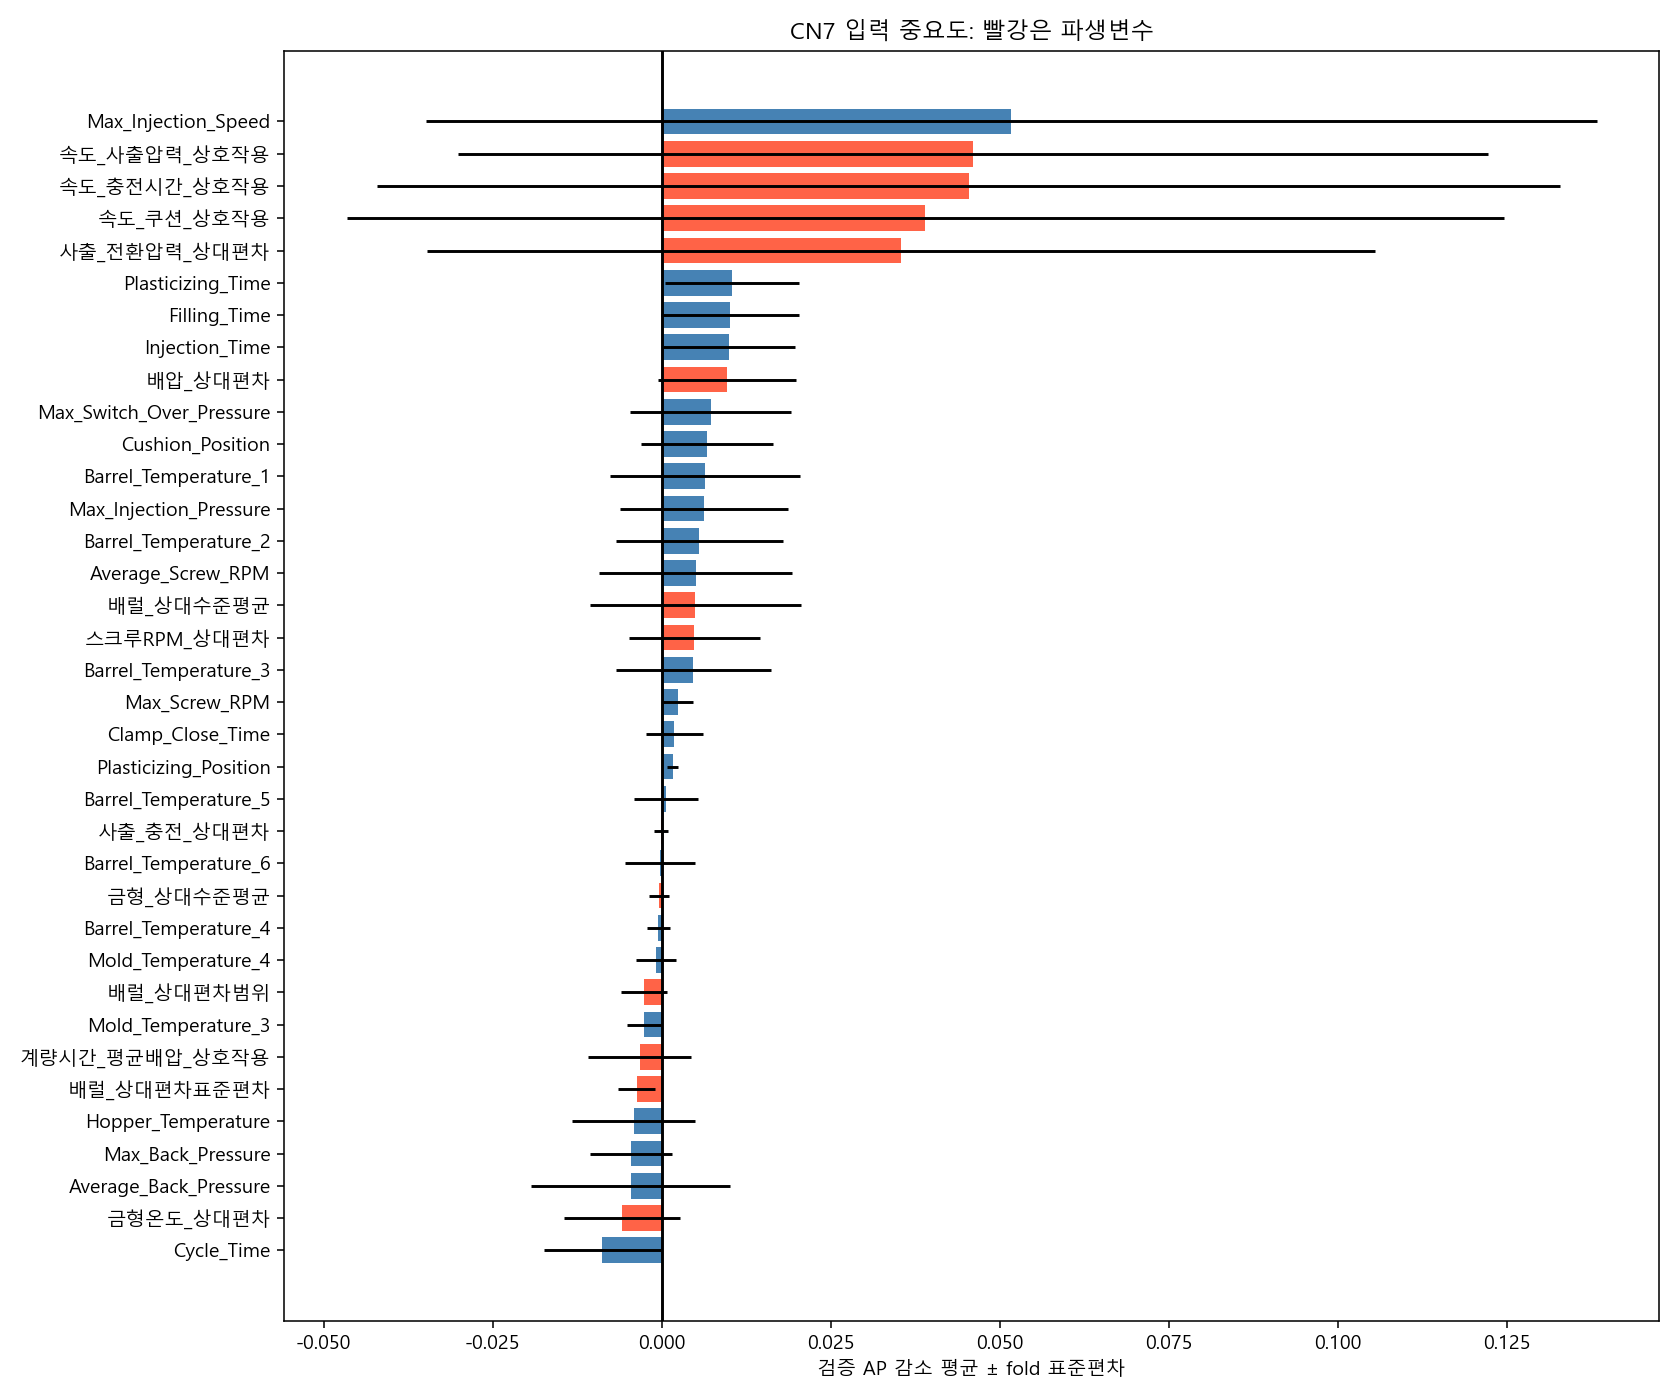

In [32]:
cycle_imp=[]
for fold,b,an,av,va in cycle_cache:
    model=OneClassSVM(kernel='rbf',nu=cycle_full['nu'],gamma=cycle_full['gamma_multiplier']/len(cycle_names),tol=1e-4,max_iter=100000).fit(an)
    assert model.fit_status_==0
    base=average_precision_score(y.iloc[va],-model.decision_function(av))
    rng=np.random.default_rng(42+fold)
    for j,feature in enumerate(cycle_names):
        for repeat in range(20):
            perm=av.copy();perm[:,j]=rng.permutation(perm[:,j])
            decrease=base-average_precision_score(y.iloc[va],-model.decision_function(perm))
            cycle_imp.append({'fold':fold,'feature':feature,'repeat':repeat,'AP_drop':decrease})
cycle_imp=pd.DataFrame(cycle_imp)
cycle_imp.to_csv(cycle_out/'importance_repeats.csv',index=False)
cycle_fold_imp=cycle_imp.groupby(['feature','fold']).AP_drop.mean().reset_index()
cycle_summary=cycle_fold_imp.groupby('feature').AP_drop.agg(['mean','std']).reset_index()
cycle_summary['positive_folds']=cycle_summary.feature.map(cycle_fold_imp.assign(positive=cycle_fold_imp.AP_drop.gt(0)).groupby('feature').positive.sum())
cycle_summary['derived']=~cycle_summary.feature.isin(X.columns)
cycle_summary=cycle_summary.sort_values('mean',ascending=False)
cycle_summary.to_csv(cycle_out/'importance_summary.csv',index=False)
originals=[c for c in cycle_names if c in X.columns]
positive=set(cycle_summary.loc[cycle_summary['mean'].gt(0),'feature'])
stable=set(cycle_summary.loc[cycle_summary['mean'].gt(0)&cycle_summary.positive_folds.ge(3),'feature'])
cycle_candidates={'full':cycle_names,'originals':originals,
    'stable_derived':[c for c in cycle_names if c in originals or c in stable],
    'positive_derived':[c for c in cycle_names if c in originals or c in positive],
    'stable_all':[c for c in cycle_names if c in stable],
    'previous_S1':[c for c in originals if c not in GROUPS['형체와 전체 주기']]}
# 동일한 입력 조합은 한 번만 탐색합니다.
cycle_unique={};cycle_alias={}
for label,names in cycle_candidates.items():
    if not names:continue
    prior=next((key for key,value in cycle_unique.items() if value==names),None)
    if prior:cycle_alias[label]=prior
    else:cycle_unique[label]=names
(cycle_out/'candidate_definitions.json').write_text(json.dumps({'candidates':cycle_unique,'aliases':cycle_alias,'rule':'mean AP drop > 0; stable also positive in >=3 of 4 folds','test_used':False},ensure_ascii=False,indent=2),encoding='utf-8')
print(cycle_summary.to_string(index=False))
print('후보별 입력 수:',{k:len(v) for k,v in cycle_unique.items()})
fig,ax=plt.subplots(figsize=(12,10));plot=cycle_summary.sort_values('mean')
ax.barh(plot.feature,plot['mean'],xerr=plot['std'].fillna(0),color=['tomato' if x else 'steelblue' for x in plot.derived])
ax.axvline(0,color='black');ax.set(xlabel='검증 AP 감소 평균 ± fold 표준편차',title='CN7 입력 중요도: 빨강은 파생변수')
fig.tight_layout();fig.savefig(cycle_out/'importance.png',dpi=140);plt.close(fig)
display(Image(filename=str(cycle_out/'importance.png')))

### C.18. 후보별 재학습과 4-fold 재검증

각 후보를 동일한 300개 파라미터 조합으로 재탐색합니다. 최고 평균 fold AP로 후보를 선택하고 정확한 동률은 후보 정의 순서로 결정합니다. F1·F2·Recall·FP도 함께 보고합니다. 임계값은 해당 후보의 개발 OOF F2로 결정하며, 각 fold의 지표는 그 공통 임계값을 적용한 개발 진단입니다.

originals 평균 AP: 0.33196330455259027 변수 수: 23
stable_derived 평균 AP: 0.31933581948976036 변수 수: 26
positive_derived 평균 AP: 0.33387106404280853 변수 수: 30
stable_all 평균 AP: 0.3894166018688032 변수 수: 11
previous_S1 평균 AP: 0.3799686651320045 변수 수: 21
       candidate    nu  gamma_multiplier  mean_AP   std_AP  feature_count  threshold       AP  ROC_AUC  precision   recall       F1       F2  TP  FP  FN  TN
      stable_all 0.025          0.030000 0.389417 0.283039             11  -0.090762 0.209735 0.809725   0.098765 0.727273 0.173913 0.320000   8  73   3 400
     previous_S1 0.010          0.038539 0.379969 0.082725             21   0.027784 0.246987 0.781280   0.666667 0.363636 0.470588 0.400000   4   2   7 471
positive_derived 0.020          0.030000 0.333871 0.131204             30   0.007767 0.228725 0.803190   0.263158 0.454545 0.333333 0.396825   5  14   6 459
       originals 0.010          0.030000 0.331963 0.123042             23   0.023736 0.173402 0.797425   0.500000 0.363636 0.4210

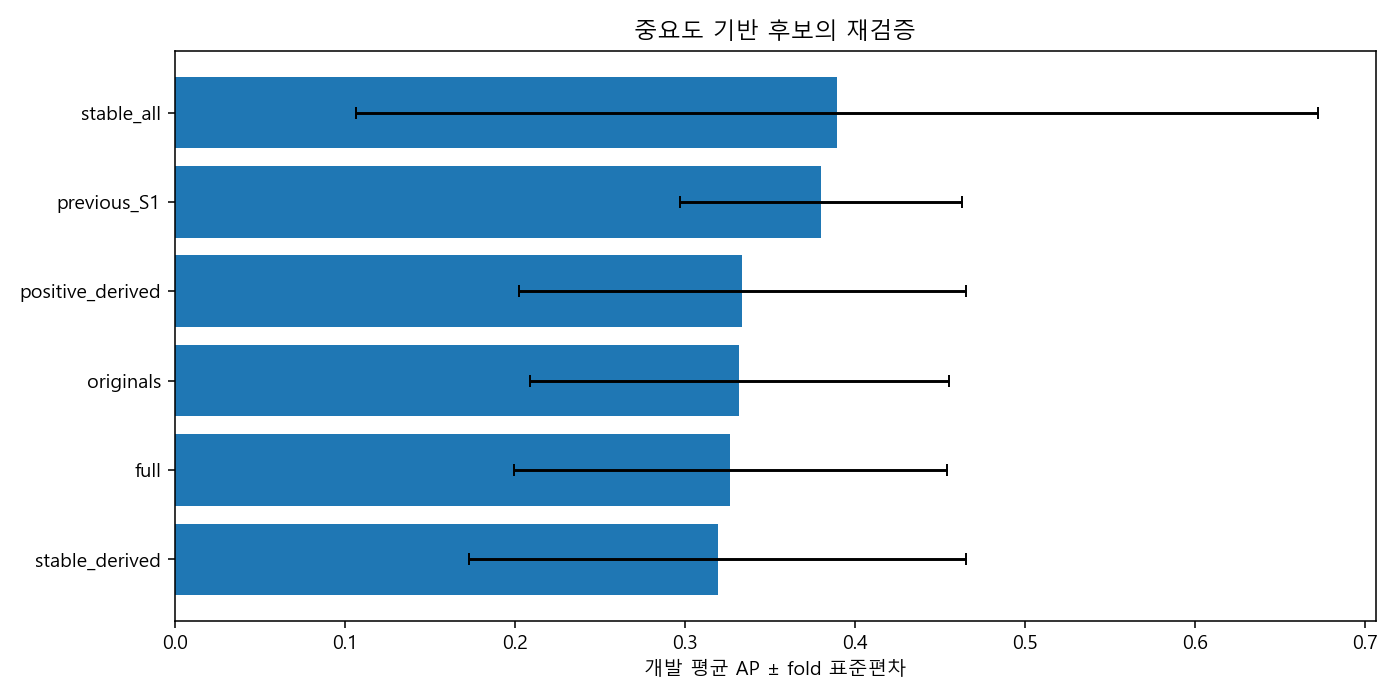

In [33]:
cycle_results={'full':cycle_full}
for label,names in cycle_unique.items():
    if label!='full':cycle_results[label]=cycle_search(label,names)
cycle_rows=[];cycle_oof=[];cycle_fold_metrics=[]
for label,result in cycle_results.items():
    threshold,_=choose_threshold(y.iloc[dev].to_numpy(),result['scores'])
    result['threshold']=float(threshold)
    cycle_rows.append({k:v for k,v in result.items() if k not in ['scores','names']}|metrics(y.iloc[dev],result['scores'],threshold))
    frame=assignment.iloc[dev][['pattern_row','pattern_id','cv_fold','label']].copy()
    frame['candidate']=label;frame['risk_score']=result['scores'];frame['threshold']=threshold
    frame['y_pred']=(frame.risk_score>threshold).astype(int);cycle_oof.append(frame)
    for fold,part in frame.groupby('cv_fold'):
        cycle_fold_metrics.append({'candidate':label,'fold':int(fold),**metrics(part.label,part.risk_score.to_numpy(),threshold)})
cycle_comparison=pd.DataFrame(cycle_rows).sort_values('mean_AP',ascending=False,kind='stable')
cycle_comparison.to_csv(cycle_out/'candidate_comparison.csv',index=False)
pd.concat(cycle_oof).to_csv(cycle_out/'oof_predictions.csv',index=False)
pd.DataFrame(cycle_fold_metrics).to_csv(cycle_out/'selected_fold_metrics.csv',index=False)
cycle_choice=str(cycle_comparison.iloc[0].candidate)
cycle_selected=cycle_results[cycle_choice]
cycle_selection={k:v for k,v in cycle_selected.items() if k!='scores'}
cycle_selection.update(selection_metric='development mean fold AP',threshold_metric='development OOF F2',test_used_for_selection=False,independent_validation=False,source_hashes=data['source_hashes'],split_hash=data['split_hash'])
(cycle_out/'selection_manifest.json').write_text(json.dumps(cycle_selection,ensure_ascii=False,indent=2),encoding='utf-8')
print(cycle_comparison.to_string(index=False))
print('확정 후보:',cycle_choice,'선택 변수:',cycle_selected['names'])
fig,ax=plt.subplots(figsize=(10,5));plot=cycle_comparison.sort_values('mean_AP')
ax.barh(plot.candidate,plot.mean_AP,xerr=plot.std_AP,capsize=3)
ax.set(xlabel='개발 평균 AP ± fold 표준편차',title='중요도 기반 후보의 재검증')
fig.tight_layout();fig.savefig(cycle_out/'candidate_comparison.png',dpi=140);plt.close(fig)
display(Image(filename=str(cycle_out/'candidate_comparison.png')))

### C.19. 개발 정상 전체 재학습과 고정 Test 후속 평가

18절에서 변수·파라미터·임계값을 저장한 후 개발 정상 전체에 변환과 모델을 다시 적합합니다. Test에는 transform과 predict만 적용합니다. 이전 test를 이미 관찰한 후속 실험이므로 독립적인 일반화 성능 증거로 해석하지 않습니다. 결과가 나빠도 test로 후보를 재선택하지 않습니다.

후속 test 결과: {'AP': 0.039887493458922035, 'ROC_AUC': 0.5322128851540616, 'precision': 0.0, 'recall': 0.0, 'F1': 0.0, 'F2': 0.0, 'TP': 0, 'FP': 12, 'FN': 3, 'TN': 107}


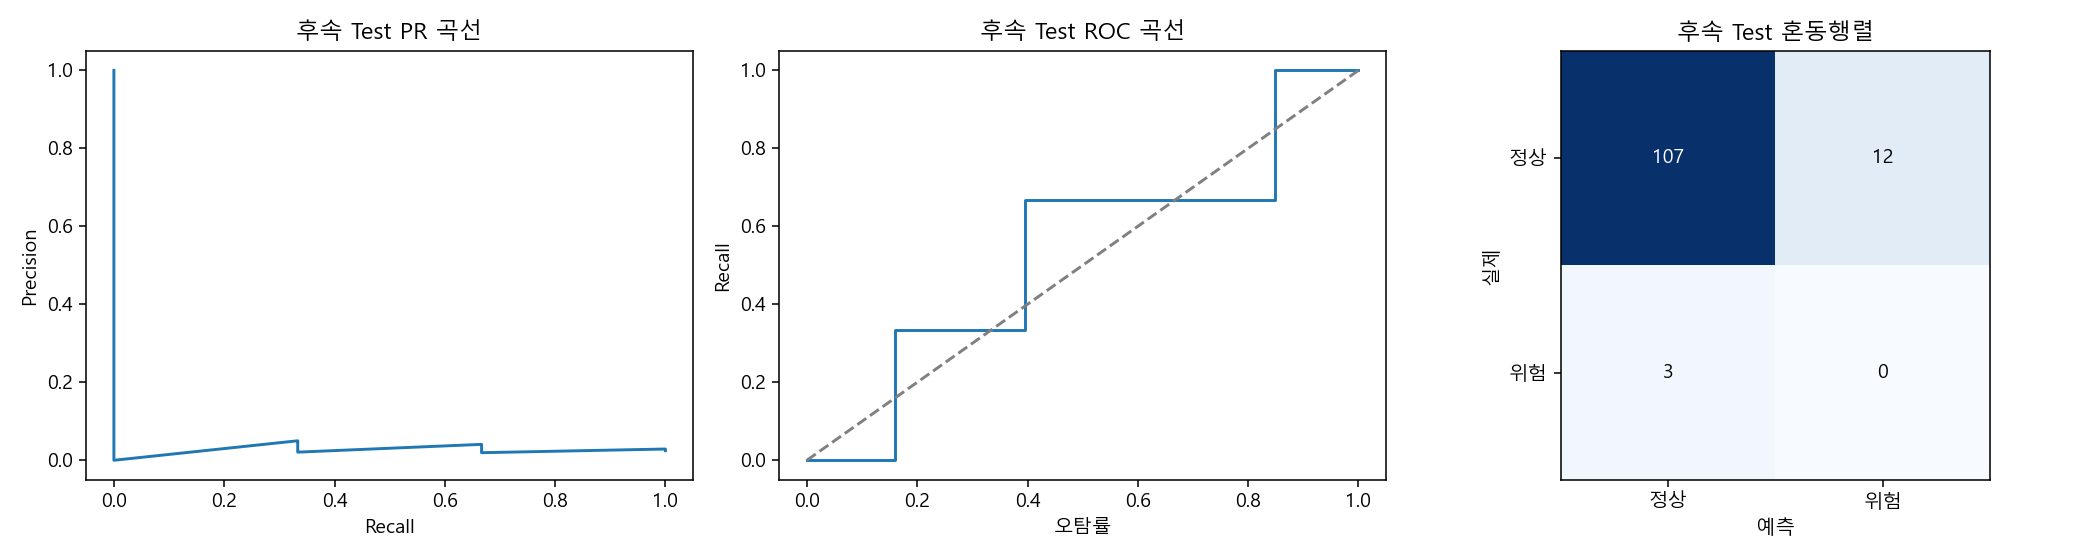

In [34]:
selection_sha=digest(cycle_out/'selection_manifest.json')
normal=dev[y.iloc[dev].to_numpy()==0]
cycle_bundle,an=cycle_fit(X.iloc[normal])
assert all(c in cycle_bundle['names'] for c in cycle_selected['names'])
indices=[cycle_bundle['names'].index(c) for c in cycle_selected['names']]
model=OneClassSVM(kernel='rbf',nu=cycle_selected['nu'],gamma=cycle_selected['gamma_multiplier']/len(indices),tol=1e-4,max_iter=100000).fit(an[:,indices])
assert model.fit_status_==0
test_rows=data['test'];truth=y.iloc[test_rows].to_numpy()
values=cycle_transform(cycle_bundle,X.iloc[test_rows])[:,indices]
scores=-model.decision_function(values);threshold=cycle_selected['threshold']
test_metrics=metrics(truth,scores,threshold)
pd.DataFrame([test_metrics]).to_csv(cycle_out/'test_metrics.csv',index=False)
pred=assignment.iloc[test_rows][['pattern_row','pattern_id','label']].copy()
pred['risk_score']=scores;pred['y_pred']=(scores>threshold).astype(int);pred['threshold']=threshold
pred.to_csv(cycle_out/'test_predictions.csv',index=False)
joblib.dump({'features':cycle_bundle,'selected_names':cycle_selected['names'],'indices':indices,'model':model,'threshold':threshold},cycle_out/'model_bundle.joblib')
loaded=joblib.load(cycle_out/'model_bundle.joblib')
reloaded=-loaded['model'].decision_function(cycle_transform(loaded['features'],X.iloc[test_rows])[:,loaded['indices']])
assert np.allclose(scores,reloaded,rtol=0,atol=1e-12)
assert digest(cycle_out/'selection_manifest.json')==selection_sha
assert all(digest(out/f)==sha for f,sha in previous_protected.items())
verification={'all_fits_converged':True,'reload_scores_equal':True,'previous_final_artifacts_unchanged':True,'selection_sha256':selection_sha,'test_used_for_selection':False,'test_previously_seen':True,'sklearn_version':sklearn.__version__,'importance_evaluations':len(cycle_imp),'candidate_count':len(cycle_results)}
(cycle_out/'verification.json').write_text(json.dumps(verification,indent=2),encoding='utf-8')
print('후속 test 결과:',test_metrics)
fig,axes=plt.subplots(1,3,figsize=(15,4))
pcurve,rcurve,_=precision_recall_curve(truth,scores);axes[0].plot(rcurve,pcurve)
axes[0].set(xlabel='Recall',ylabel='Precision',title='후속 Test PR 곡선')
fpr,tpr,_=roc_curve(truth,scores);axes[1].plot(fpr,tpr);axes[1].plot([0,1],[0,1],'--',color='gray')
axes[1].set(xlabel='오탐률',ylabel='Recall',title='후속 Test ROC 곡선')
cm=confusion_matrix(truth,pred.y_pred,labels=[0,1]);axes[2].imshow(cm,cmap='Blues')
for i in range(2):
    for j in range(2):axes[2].text(j,i,str(cm[i,j]),ha='center',va='center',color='white' if cm[i,j]>cm.max()/2 else 'black')
axes[2].set(xticks=[0,1],yticks=[0,1],xticklabels=['정상','위험'],yticklabels=['정상','위험'],xlabel='예측',ylabel='실제',title='후속 Test 혼동행렬')
fig.tight_layout();fig.savefig(cycle_out/'test_evaluation.png',dpi=140);plt.close(fig)
display(Image(filename=str(cycle_out/'test_evaluation.png')))

### C.20. 재검증 결과 요약

아래 요약은 실행 결과에서 생성합니다. 중요도와 재검증은 모두 개발 데이터 기반이며 최종 test는 선택에 사용하지 않았습니다. 상관된 파생변수의 개별 permutation 결과만으로 공정 원인을 단정하지 않습니다.

In [35]:
summary_text=(f"선택 후보: {cycle_choice}\n입력 수: {len(cycle_selected['names'])}\n"
    f"개발 평균 AP: {cycle_selected['mean_AP']:.6f} (전체 입력: {cycle_full['mean_AP']:.6f})\n"
    f"Test TP={test_metrics['TP']}, FP={test_metrics['FP']}, FN={test_metrics['FN']}, TN={test_metrics['TN']}\n"
    f"Test F1={test_metrics['F1']:.6f}, F2={test_metrics['F2']:.6f}, AP={test_metrics['AP']:.6f}\n"
    "검증 데이터를 반복 사용한 개발 선택이며, 이미 관찰한 test의 후속 평가입니다.\n"
    "기존 test 결과에 맞춰 변수를 선택한 것은 아니지만, 독립 검증은 새 데이터가 필요합니다.")
print(summary_text)
(cycle_out/'analysis_summary.md').write_text('# CN7 중요도 기반 변수 선택 후속 실험\n\n'+summary_text,encoding='utf-8')

선택 후보: stable_all
입력 수: 11
개발 평균 AP: 0.389417 (전체 입력: 0.326780)
Test TP=0, FP=12, FN=3, TN=107
Test F1=0.000000, F2=0.000000, AP=0.039887
검증 데이터를 반복 사용한 개발 선택이며, 이미 관찰한 test의 후속 평가입니다.
기존 test 결과에 맞춰 변수를 선택한 것은 아니지만, 독립 검증은 새 데이터가 필요합니다.


#### 이번 실행의 해석

평균 검증 AP 기준으로 선택된 `stable_all`은 원변수 8개와 파생변수 3개(배압 상대편차, 사출·전환압력 상대편차, 속도·사출압력 상호작용), 총 11개 입력입니다. 명칭의 stable은 중요도가 4-fold 중 3개 이상에서 양수라는 후보 생성 규칙을 뜻하며 **모델 성능이 안정적이라는 의미는 아닙니다.**

평균 AP는 기존 S1의 0.37997에서 0.38942로 소폭 높아졌지만 fold 표준편차는 0.08272에서 0.28304로 커졌습니다. 개발 OOF F2는 0.400에서 0.320으로 낮아졌고 FP는 2개에서 73개로 늘었습니다. 평균 fold AP와 통합 OOF AP는 서로 다른 집계이며, fold마다 적합한 모델의 원시 점수 척도가 같다고 보장되지 않습니다.

고정 test 후속 평가에서는 TP=0, FP=12, FN=3, TN=107, AP=0.03989, ROC-AUC=0.53221입니다. 기존 S1 후속 평가의 TP=0, FP=0보다 오탐이 늘었으며, **변수 선택이 실제 탐지 성능을 개선했다는 근거는 없습니다.** 선택 규칙이 평균 AP 하나였기 때문에 이 후보가 선택된 사실과, 운영상 적절한 모델이라는 판단은 구분해야 합니다.

Test 결과로 기존 모델에 다시 되돌려 선택하거나 임계값을 조정하지 않았습니다. 다음 실험에서 안정성·오탐량을 선택 제약에 넣으려면 개발 데이터에서 규칙을 먼저 정하고 검증해야 합니다. 이미 사용한 test에 대한 반복 개선 결과는 독립 검증으로 보고하지 않습니다.
